# Instructions

To run any cell, make sure to run the globals cells first. You must import the pip package from github at least once and runthe globals cell before any other cells.

Exploratory Data Analysis, Data Preparation, and Data Cleaning Pipeline import the csv data, exlore the feature, and run through initial cleaning and the process of feature engineering.

The **Modeling Runs** section contains the model testing pipeline for 8 different models. More details about the process are in that section.

Many of these sections take a long time to run. They all run a 5-fold CV and running 150 fits on a hyperparameter search takes a long time. The cells have all been run at least once and the runtime for each is printed with its output. Some cells take over 30 minutes.

# Globals

In [ ]:
# # import project code from github
# !pip uninstall -y shared_util
# %pip -q install 'git+https://github.com/meaton96/Eaton_633_Project.git'

Found existing installation: shared_util 0.1.0
Uninstalling shared_util-0.1.0:
  Successfully uninstalled shared_util-0.1.0
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'git+https://github.com/meaton96/Eaton_633_Project.git'"

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Globals
import numpy as np
import pandas as pd
from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 32
METRICS_NOTES = "ordinal_a1c_gluc"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)

R = 16_300 # Average cost of readmission (Jiang and Hensche, 2023)
e = 0.33 # estimated program effectiveness - estimate 33% for target cohort, studies show >50%, unknown readmission cause, no study on target cohort, so lowered
m_cost_list = [150, 220, 330, 440, 660, 1000] # program costs 30-60 days, $150-$220 per patient per month
COST_PREF = 330 # 1 month monitoring cost


UPDATE_DATABASE = False # keep false in collab, will crash, this controls if the runs try to log to the database, which will not work witout the db uri
GET_BASELINE = False    # controls if a baseline smote vs undersample is done for this run
SHOW_FEAT_IMPORTANCE = False # controls if feature importance is shown for this run
USE_PRE_COMPUTED_HYPERPARAMS = True # controls if hyperparam sweep is run or to use hyperparams from previous runs

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', #'number_inpatient'
     ])

# Exploratory Data Analysis

In [3]:
import pandas as pd
from shared_util.dataio import load_csv

df = load_csv('diabetic_data')

df = df.reset_index().rename(columns={'index': 'encounter_id'})


display(df.head())

X = df.drop(columns=['readmitted'])
y = df['readmitted']

y = pd.DataFrame(y)
y.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


In [12]:
print(X.columns.to_list())

X['A1Cresult'].unique()

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


array([nan, '>7', '>8', 'Norm'], dtype=object)

In [7]:
len(X['number_inpatient'].unique())

21

### Discharge Disposition

Certain row-level exclusions must be applied before splitting the data, because they define the population on which the model would realistically be used. Several discharge disposition codes (e.g., inpatient transfers, hospice care, expired patients) represent encounters that would never be eligible for 30-day readmission intervention. Including them in validation or test sets would result in evaluating model performance on cases that are out-of-scope for the prediction task and would not appear in future deployment.

These exclusions are cohort-definition steps, not statistical preprocessing, and therefore do not introduce information leakage.

In [5]:
# Examine the discharge disposition data
# From accompanying mapping documentation:
discharge_disposition_map = {
    1: "Discharged to home",
    2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF",
    4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA",
    8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital",
    10: "Neonate discharged to another hospital for neonatal aftercare",
    11: "Expired",
    12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home. Medicaid only, hospice.",
    20: "Expired in a medical facility. Medicaid only, hospice.",
    21: "Expired, place unknown. Medicaid only, hospice.",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital.",
    23: "Discharged/transferred to a long term care hospital.",
    24: "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility.",
    28: "Discharged/transferred/referred to a psychiatric hospital or psychiatric distinct part unit of a hospital",
    29: "Discharged/transferred to a Critical Access Hospital (CAH).",
    30: "Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere"
}

X_discharge = X['discharge_disposition_id'].map(discharge_disposition_map)

X_discharge.value_counts()

discharge_disposition_id
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital.                              1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                             

Several of these values are problematic.

Some rows note that patients have expired. This would not be known at time of discharge and needs to be removed from our dataset.

Additionaly, there are a large amount of rows that show patients were transfered to another inpatient facility. These patients are not discharged and are therefore not part of our target cohort.

### Statistical EDA

In [6]:
# split off training data, training is 70%, validation 15%, test 15% but we just look at training data
# full stratified-group split code
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

def group_split(
    df: pd.DataFrame,
    *,
    target_col: str = "target",
    group_col: str = "patient_nbr",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    balance_tolerance: float = 0.01,
    max_tries: int = 50,
):
    """
    Group-aware split (no patient leakage) into train/val/test.
    Uses two GroupShuffleSplits: (train vs rest), then (val vs test) on the rest.
    Attempts to keep class prevalence close to overall within 'balance_tolerance'.
    """
    rng = np.random.RandomState(random_state)
    overall_rate = df[target_col].mean()

    def _ok_rate(d: pd.DataFrame) -> bool:
        if d.empty:
            return False
        return abs(d[target_col].mean() - overall_rate) <= balance_tolerance

    # 1) Train vs rest
    tries = 0
    while True:
        gss = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=rng.randint(0, 10**9))
        tr_idx, rest_idx = next(gss.split(df, df[target_col], groups=df[group_col]))
        train_df = df.iloc[tr_idx].copy()
        rest_df  = df.iloc[rest_idx].copy()
        if _ok_rate(train_df) and _ok_rate(rest_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # 2) Val vs Test on the remaining groups
    rel_val = val_size / (val_size + test_size)
    tries = 0
    while True:
        gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=rng.randint(0, 10**9))
        val_idx_rel, test_idx_rel = next(gss2.split(rest_df, rest_df[target_col], groups=rest_df[group_col]))
        val_df  = rest_df.iloc[val_idx_rel].copy()
        test_df = rest_df.iloc[test_idx_rel].copy()
        if _ok_rate(val_df) and _ok_rate(test_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # leak test: no patient overlap
    tr_pat, va_pat, te_pat = set(train_df[group_col]), set(val_df[group_col]), set(test_df[group_col])
    assert tr_pat.isdisjoint(va_pat) and tr_pat.isdisjoint(te_pat) and va_pat.isdisjoint(te_pat), \
        "Patient overlap detected across splits."

    # return X/y splits
    def _xy(d: pd.DataFrame):
        X = d.drop(columns=[target_col])
        y = d[target_col].copy()
        return X, y

    X_train, y_train = _xy(train_df)
    X_val,   y_val   = _xy(val_df)
    X_test,  y_test  = _xy(test_df)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
# the group split function expects a somewhat cleaned up data set, at least with the target variable setup (binary stratification)

df['target'] = (df['readmitted'] == '<30').astype(int)


X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

In [8]:
# statistical summary of continuous columns

cont_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

num_df = X_train[cont_cols].dropna()

num_df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000
mean,4.388661,43.047991,1.341414,16.005446,0.362567,0.196724,0.640675,7.416875
std,2.977042,19.681216,1.708255,8.121455,1.239948,0.852492,1.271679,1.936508
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,40.000000,37.000000,19.000000,16.000000


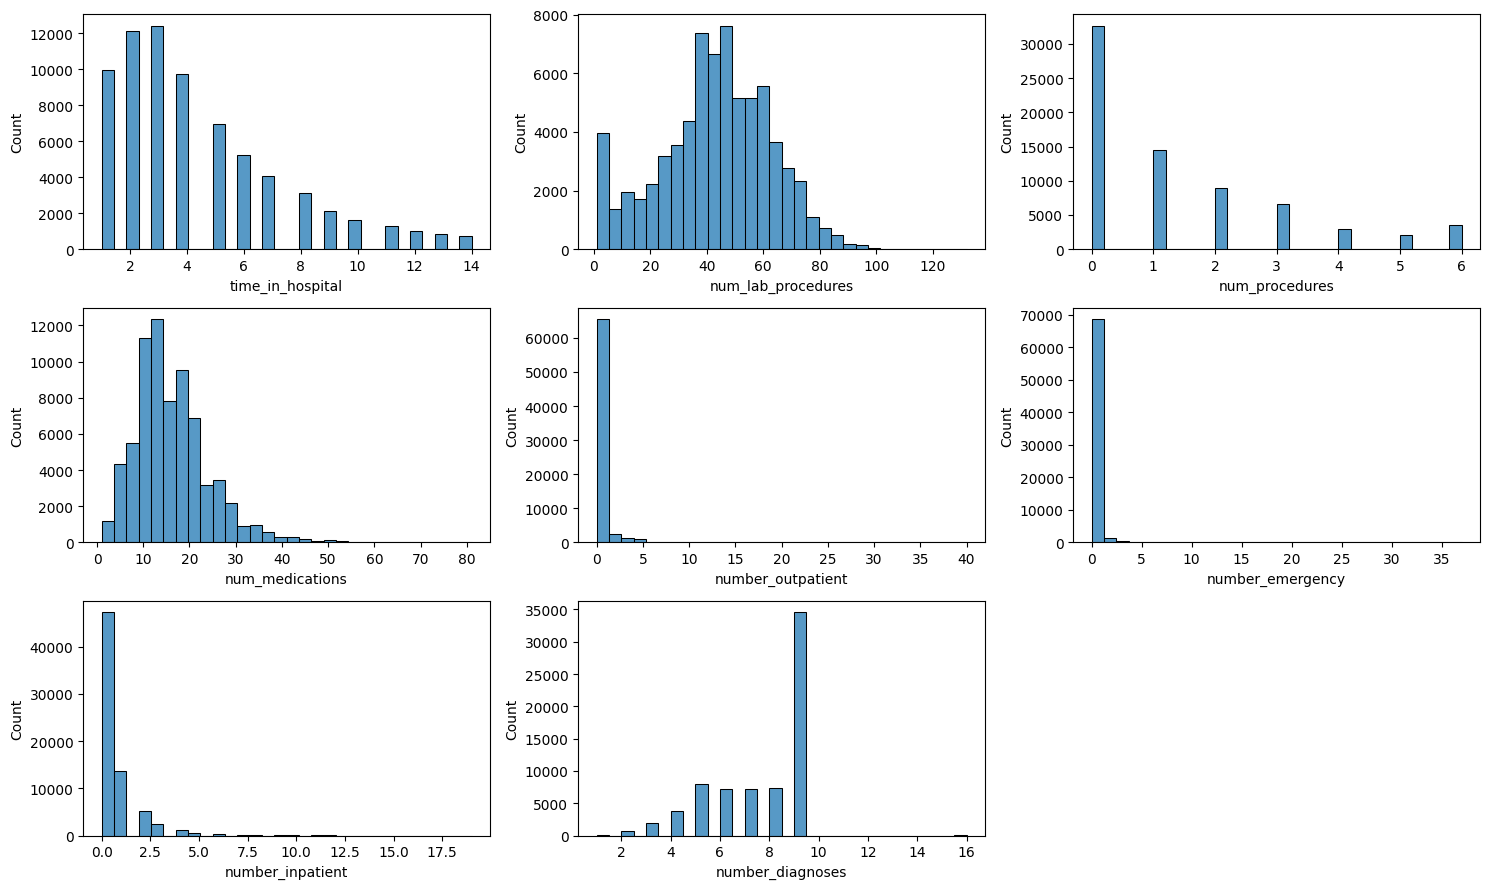

In [9]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def cont_hist_plots(num_feats_df):
    cols = num_feats_df.columns.tolist()
    n = len(cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = num_feats_df[col].dropna()
        bins = 30
        sns.histplot(data, bins=bins, kde=False, ax=ax, color="C0", stat="count") # type: ignore

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

cont_hist_plots(num_df)

Many right very right-skewed features

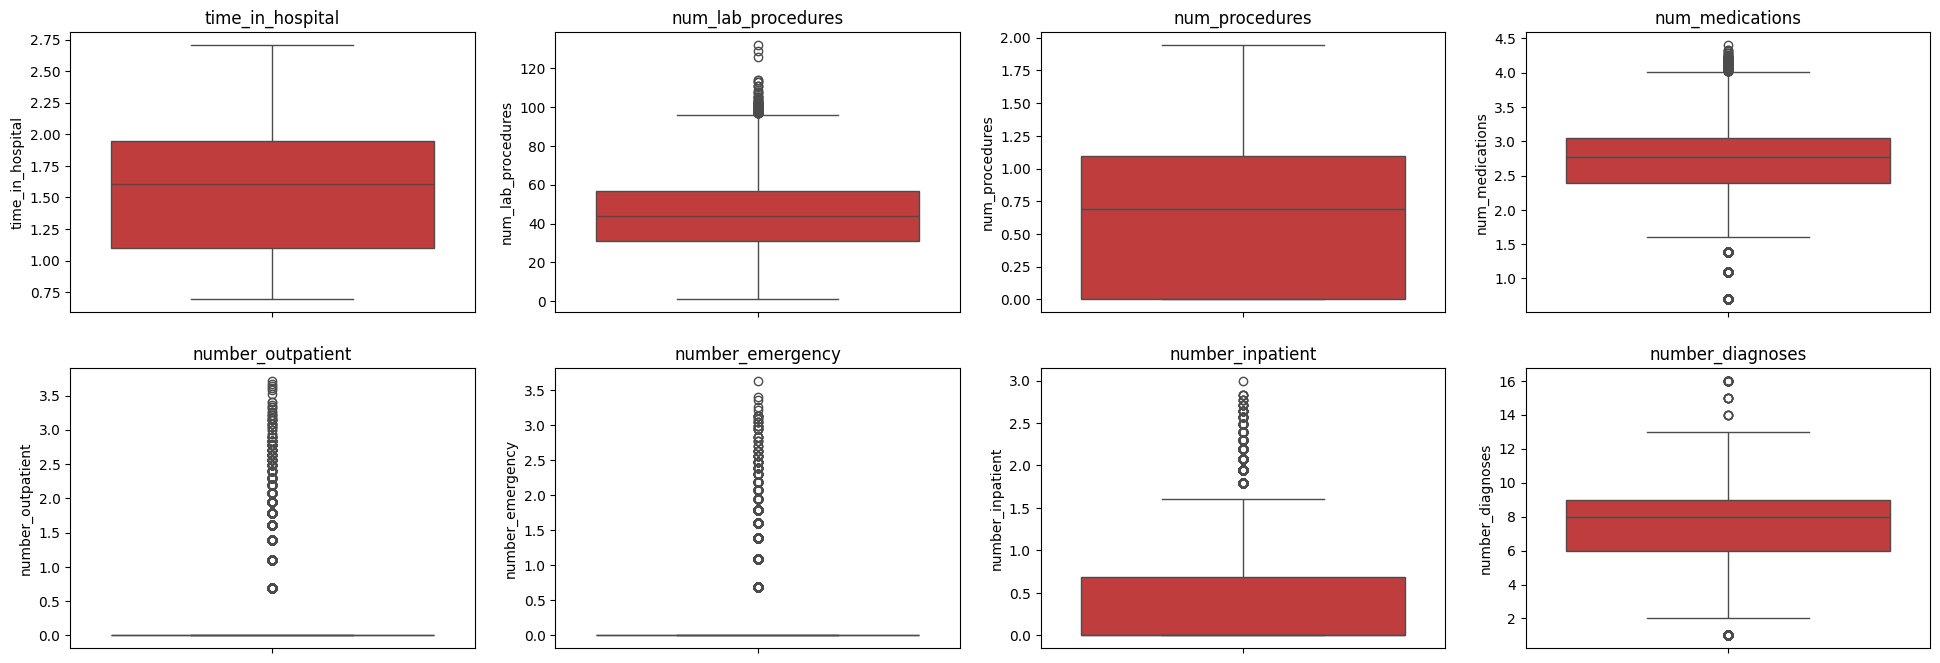

In [10]:
# box plots, looking for outliers

num_df_log = num_df.copy()

# linear models will transform these columns in pre processing pipeline
cont_cols = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency',
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])



num_df_log[cont_cols] = np.log1p(num_df_log[cont_cols].dropna())

cols = num_df_log.columns.to_list()


fig, axes = plt.subplots(2,4, figsize=(len(cols)*3, 8))
axes = axes.flatten()
if len(cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cols):
    sns.boxplot(y=num_df_log[col], ax=ax, color='C3')
    ax.set_title(col)
    ax.set_xlabel('')

plt.show()

In [11]:
# transform cols
#df['readmitted'] = (df['readmitted'] == '<30').astype(int)
df[cont_cols] = np.log1p(df[cont_cols])
df_train = pd.concat([X_train, y_train], axis=1)

Examine continous feature variance between classes.

Some features show a large amount of outliers, a vast majority of 0s and are very skewed.

Checking if this distribution is varied between classes.

ex. Do none of the readmitted patients have 0 outpatient procedures?

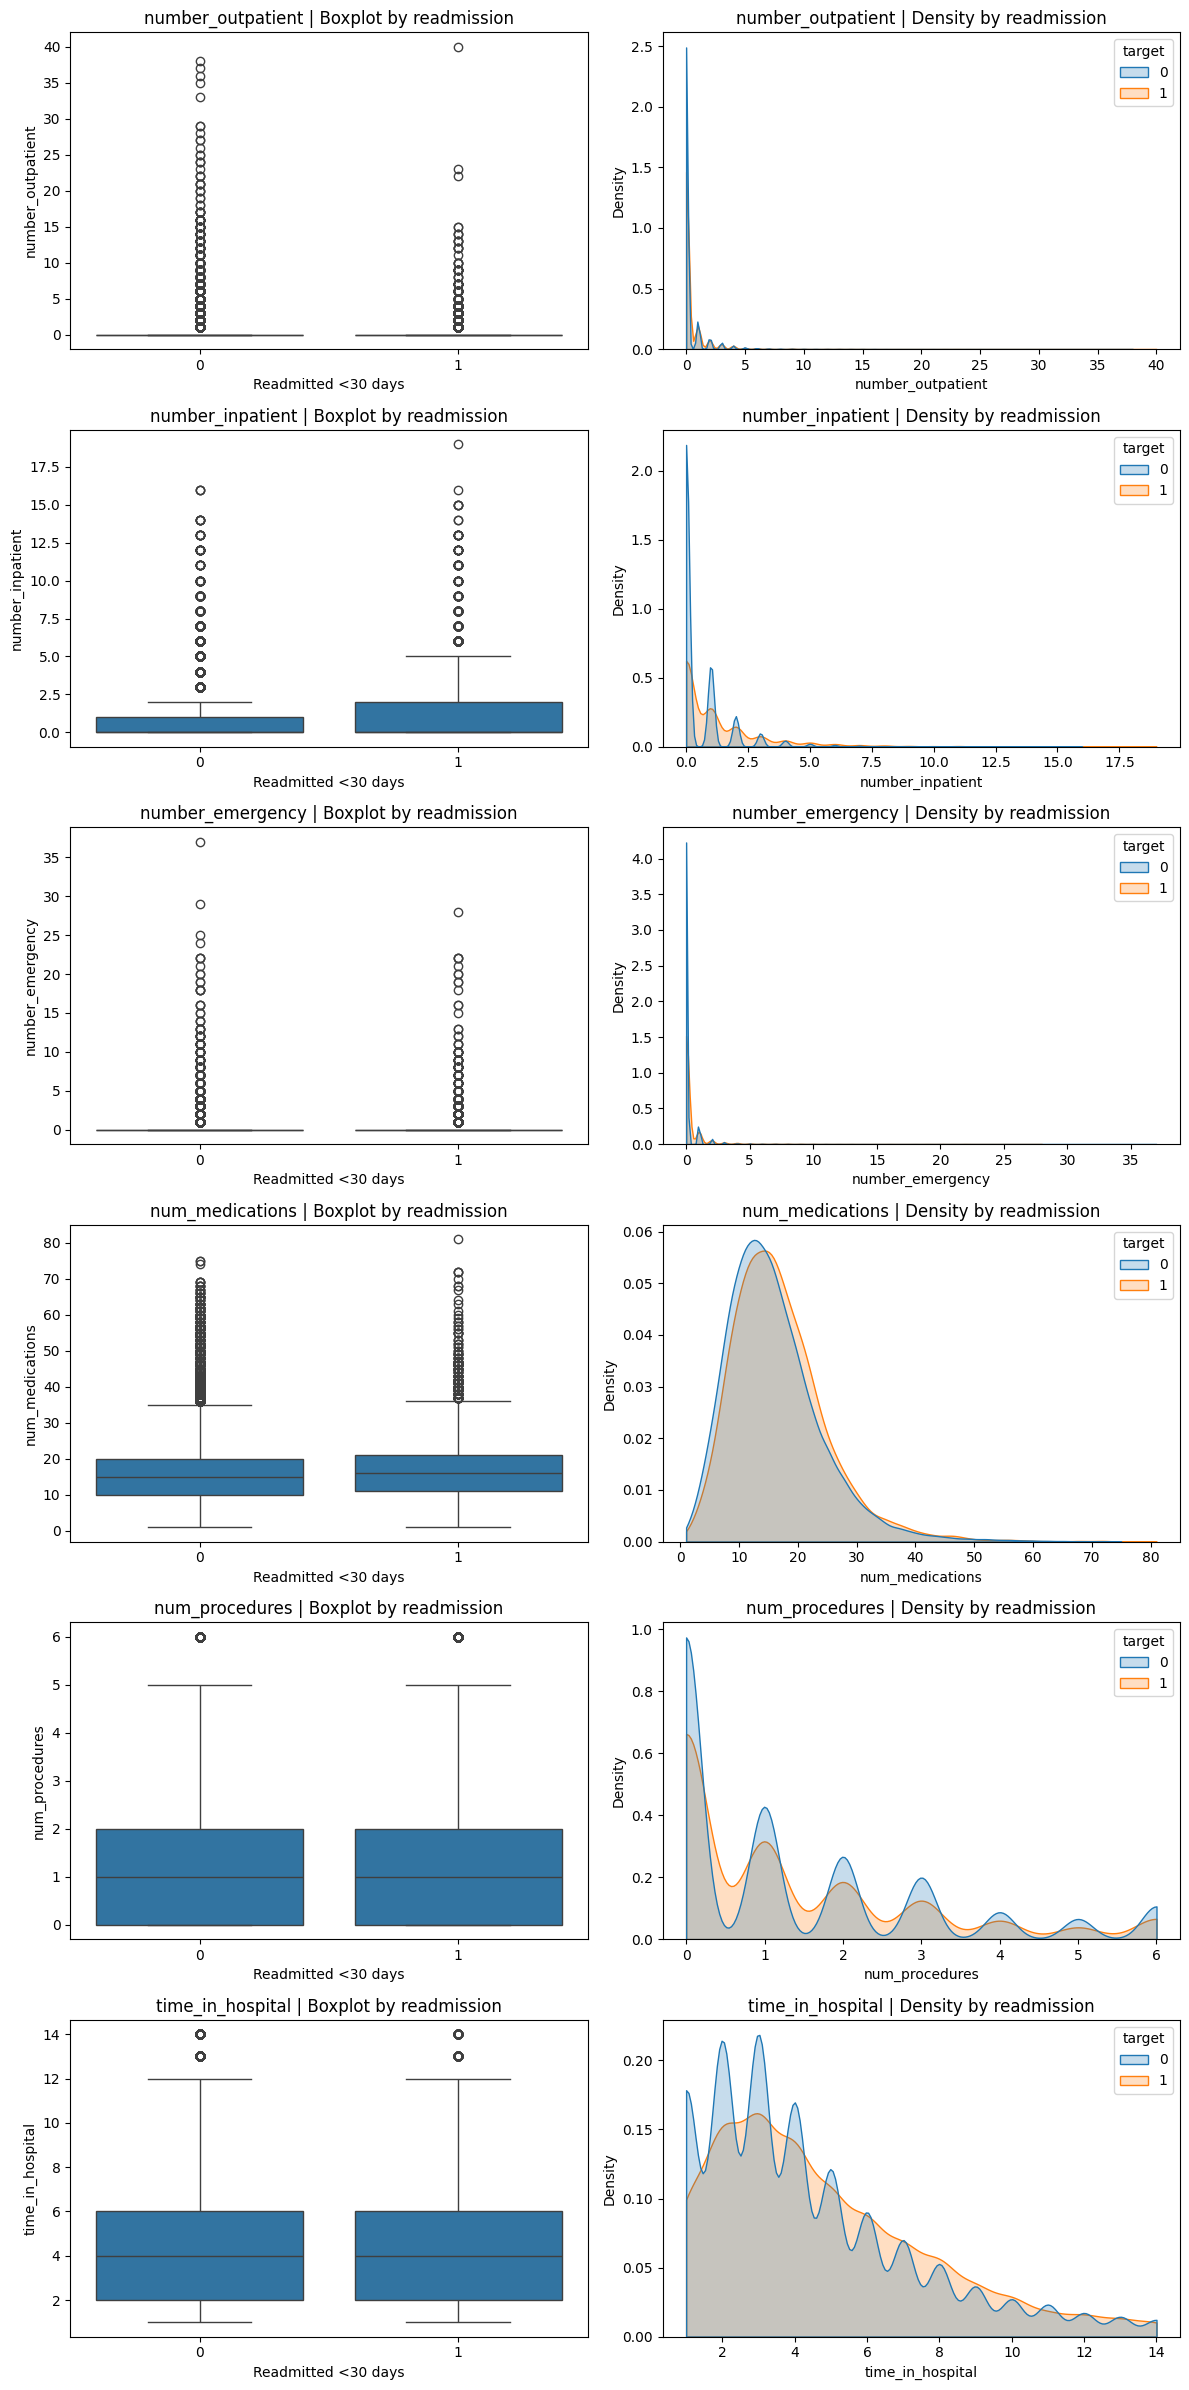

In [12]:
fig, axes = plt.subplots(len(cont_cols), 2, figsize=(12, 4 * len(cont_cols)))
for i, col in enumerate(cont_cols):
    sns.boxplot(
        data=df_train,
        x="target",
        y=col,
        ax=axes[i, 0],
        showfliers=True
    )
    axes[i, 0].set_title(f"{col} | Boxplot by readmission")
    axes[i, 0].set_xlabel("Readmitted <30 days")
    axes[i, 0].set_ylabel(col)

    sns.kdeplot(
        data=df_train,
        x=col,
        hue="target",
        common_norm=False,
        fill=True,
        ax=axes[i, 1],
        cut=0,
    )
    axes[i, 1].set_title(f"{col} | Density by readmission")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

The only feature that may show some variance difference between classes is num_inpatient which makes sense given its powerful predicitive value.

The density plot in particular shows a much larger grouping around 0 for number_inpatient for the negative class.

The boxplots show that the non-readmitted class has a decently lower upper quartile compared with the readmitted patients

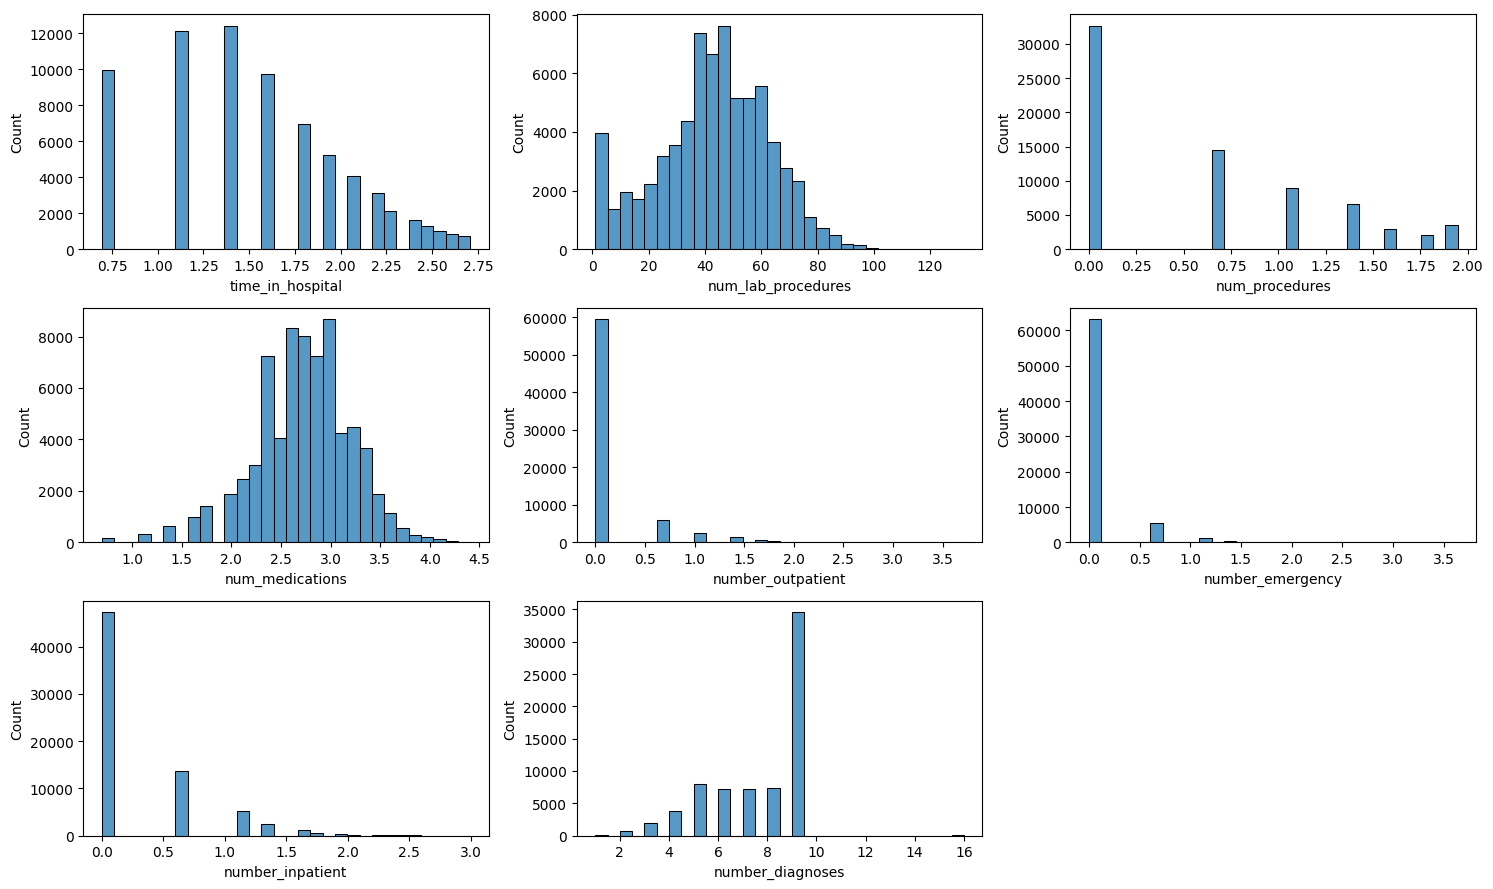

In [13]:
# check hist plots again after transform
cont_hist_plots(num_df_log)

some columns show improvement in psuedonormalization after log transform

time_in_hospotal, num_lab_procedures, num_medications all seem approximately bell shaped

Other columns still show poor statistical distribution and may need further transformation

### Pip Data

In [14]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X_pip: pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.features  # type: ignore
y_pip :pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.targets.copy()  # type: ignore

In [16]:
_df = X_train.copy()

In [17]:
print(f'csv: feature num={len(_df.columns)}')
print(f'python import: feature num={len(X_pip.columns)}')

csv: feature num=50
python import: feature num=47


data imported from the pip package is missing patient_nbr and encounter_id
<hr>

### Examine feature names

In [18]:
_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

### Repeat Patients

In [19]:
_df['patient_nbr'].value_counts()

patient_nbr
88785891     40
88227540     23
1660293      23
23199021     23
84428613     22
             ..
184875899     1
183087545     1
188574944     1
140199494     1
86383710      1
Name: count, Length: 50062, dtype: int64

Multiple repeated patient encounters, one patient number shows up 40 times
<hr>

### Examine class balance

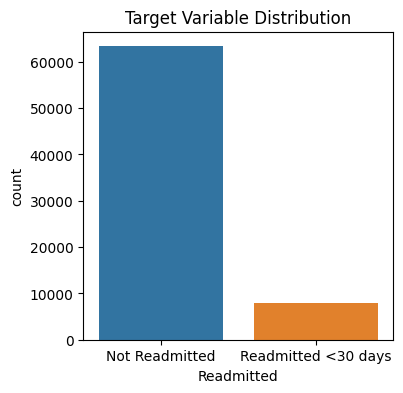

Percent Readmitted In under 30 days (Training Set): 11.11%


In [20]:
# target distribution

plt.figure(figsize=(4,4))

label_map = {0: 'Not Readmitted', 1: 'Readmitted <30 days'}


y_plt = y_train.map(label_map)


sns.countplot(x=y_plt, hue=y_plt)


plt.title('Target Variable Distribution')
plt.xlabel('Readmitted')
plt.ylabel('count')

plt.show()
print(f'Percent Readmitted In under 30 days (Training Set): {y_train.mean()*100:.2f}%')

The target class is extremely imbalanced. This will be addressed later on with an over or under sampling technique.

<HR>

### Missing Data

In [21]:
# to address nans we need to convert to proper dtypes first
# fix diag column types
X_train['diag_1'] = X_train['diag_1'].astype('string')
X_train['diag_2'] = X_train['diag_2'].astype('string')
X_train['diag_3'] = X_train['diag_3'].astype('string')

# fix specialty column type
X_train['medical_specialty'] = X_train['medical_specialty'].astype('string').replace("?", np.nan)

X_train['weight'] = X_train['weight'].replace("?", np.nan)


# fix race
X_train['race'] = X_train['race'].astype('string')

# fix age
X_train['age'] = X_train['age'].astype('string')

X_train['change'] = X_train['change'].astype('string')


,n_missing,pct_missing
weight,69018,96.88
max_glu_serum,67531,94.79
A1Cresult,59309,83.25
medical_specialty,34931,49.03
patient_nbr,0,0.00
encounter_id,0,0.00
admission_type_id,0,0.00
discharge_disposition_id,0,0.00
gender,0,0.00
race,0,0.00


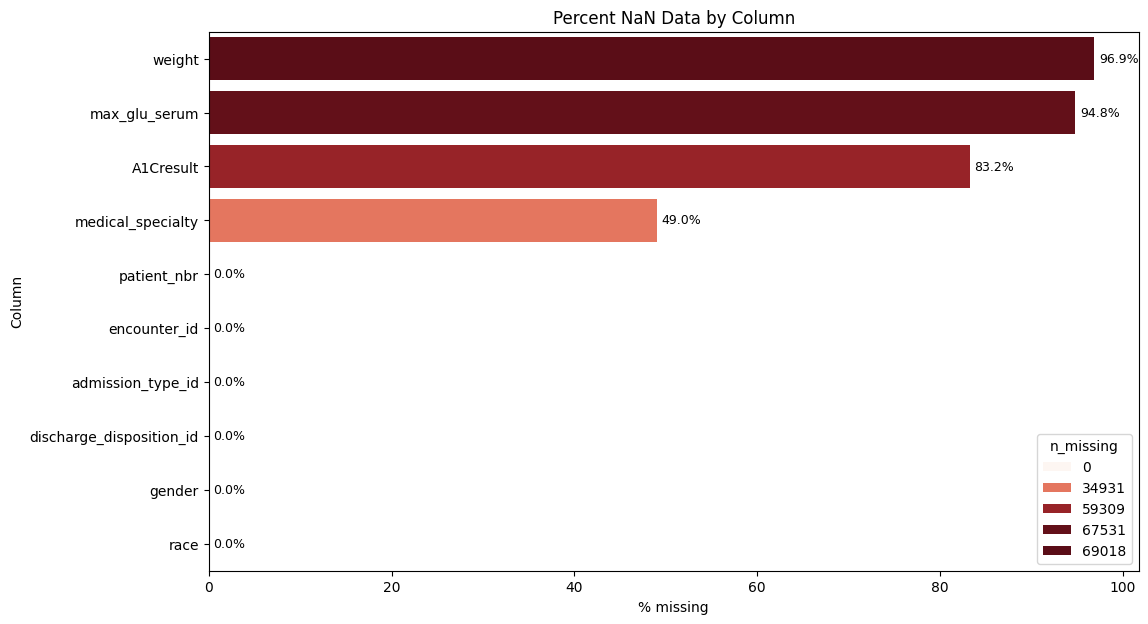

In [22]:
missing = X_train.isna().sum().to_frame(name='n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(X_train) * 100).round(2)
missing = missing.sort_values('pct_missing', ascending=False)
display(missing.head(10))

top_missing = missing.head(10).reset_index().rename(columns={'index':'column'})

plt.figure(figsize=(12,7))


sns.barplot(data=top_missing, x='pct_missing', y='column', palette='Reds', hue='n_missing' )
plt.title('Percent NaN Data by Column')
plt.xlabel('% missing')
plt.ylabel('Column')

for i, pct in enumerate(top_missing['pct_missing']):
    plt.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.show()

Weight, as we knew, is extremely sparse. As stated in Strack et al. we can also see that A1CResult has ~83% missing, the focus of their study.

Payer Code shows almost 40% missing, and will be dropped later on as not being useful in prediction.

Medical specialy is ~50% missing but is kept as a decent indicator of readmission.

# Data Preparation

### Read In Data

In [23]:
import pandas as pd
import numpy as np
# read in data
from shared_util.dataio import load_csv

df = load_csv('diabetic_data')

df = df.reset_index().rename(columns={'index': 'encounter_id'})


display(df.head())

X = df.drop(columns=['readmitted'])
y = df['readmitted']

y = pd.DataFrame(y)
y.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


### Fix DTypes

In [24]:
# to address nans we need to convert to proper dtypes first
# fix diag column types
X['diag_1'] = X['diag_1'].astype('string')
X['diag_2'] = X['diag_2'].astype('string')
X['diag_3'] = X['diag_3'].astype('string')

# fix specialty column type
X['medical_specialty'] = X['medical_specialty'].astype('string').replace("?", np.nan)




# fix race
X['race'] = X['race'].astype('string')

# fix age
X['age'] = X['age'].astype('string')

X['change'] = X['change'].astype('string')


### Derive Target

In [25]:
y['readmitted'] = y['readmitted'].astype('string')

y['target'] = (y['readmitted'] == '<30').astype(int)

### Drop Payer_Code

In [26]:
# drop payer_code missing and un informative
X_0 = X.drop(columns=['payer_code'])

### Row-wise Cleaning

Class balance before row cleaning

In [27]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 11.16%


Address encounters that are not part of our target cohort.

As stated above, these drops are here to define our target cohort. In deployment, we would never be looking at patients who are transferred inpatient, we are only interested in patients at time of **discharge from the hospital**.

More specifically, we are looking to predict, at time of discharge, if an **adult** will be readmitted to the hospital wihin 90 days.

Several rows break the rules of our target study and need to be dropped.

Splitting before dropping these rows, would leave patients who would never, in practice, be predicted on, in our test and validation sets and would skew metrics.

Furthermore, there is a small subset of *discharge_disposition_id* values that leak future information that would not be known at discharge time.

In [28]:
# drop the newborn rows
#The dataset contains newborn encounters
# despite the original Diabetes 130-US study being restricted to adult patients (≥18 years).
non_adult = (X_0['admission_type_id'] == 4) | (X_0['discharge_disposition_id'] == 10) | (X_0['age'] == '[0-10)') | (X_0['age'] == '[10-20)')

_pre = len(X_0)


X_1 = X_0.loc[~non_adult].reset_index(drop=True)
y   = y.loc[~non_adult].reset_index(drop=True)
print(f'dropped: {_pre - len(X_1)}')

dropped: 867


In [29]:
# drop rows that show a patient expired

# from mapping info
_c = 'discharge_disposition_id'

expired_ids = [11, 19, 20]
X_2 = X_1.copy()

exp_mask = X_2[_c].isin(expired_ids)

_pre = len(X_2)
X_3 = X_2.loc[~exp_mask].reset_index(drop=True)
y   = y.loc[~exp_mask].reset_index(drop=True)
print(f'dropped: {_pre - len(X_3)}')

dropped: 1650


In [30]:
# drop rows of patients who were transferred (not discharged)
transferred_ids = [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]
trans_mask = X_3[_c].isin(transferred_ids)
_pre = len(X_3)
X_3 = X_3.loc[~trans_mask].reset_index(drop=True)
y = y.loc[~trans_mask].reset_index(drop=True)
print(f'dropped {_pre - len(X_3)}')

dropped 20728


Export cleaned up data to csv

In [31]:
print(f'{len(X_3)} rows after cleaning')
print(f'len y={len(y['target'])}')
X_3_w = pd.concat([X_3, y['target']], axis=1)
#X_3_w.to_csv('cleaned')

78521 rows after cleaning
len y=78521


Class balance post cleaning

In [32]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 10.07%


A reduction here makes sense since patients who were transferred to an inpatient facility and not discharged in this data set would be the sickest patients of the set since they were not discharged. It would make sense these patients would have the highest readmission rate.

# Data Cleaning Pipeline

After initial row wise drops of bad data, the data was exported to csv. This data is the data read in to each cleaning pipeline.

This pipeline runs inside an sklearn (imblearn) pipeline to transform data across train/validate/test splits and cross validation folds without leaking global data beween splits or folds

The below code is illustrative of this process.

In [2]:
# Read data in and split
from shared_util.dataio import load_csv
from shared_util.split import group_split

df = load_csv('cleaned') # initial data starting point saved from above preparation process used to define the target cohort
display(len(df))
X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

78521

### Feature Transformation

Bin, organize, impute missing data, drop some un-needed columns.

The strategy that follows is based off of the strategy performed by Strack et al. in their study:

*Impact of HbA1c Measurement on Hospital Readmission Rates:
Analysis of 70,000 Clinical Database Patient Records*

### Addressing the Weight Problem

The weight feature contains 97% missing values and the remaining entries are categorical ranges. Because imputing numeric estimates would require strong assumptions about within-range weight distributions and would inject artificial structure into the data, the column was retained as a nominal categorical variable.

Missing values were encoded as an explicit “missing” category to preserve information without introducing bias from synthetic imputation.

In [3]:
# encode missing
X_train['weight'] = X_train['weight'].replace("?", 'missing')

display(X_train['weight'].value_counts())

# weight will be one-hot encoded, we need to fix the value names so they dont break xgboost

weight_map = {
   'missing': 'missing',
   '[75-100)' : '75-100',
   '[50-75)' : '50-75',
   '[100-125)' : '100-125',
   '[125-150)' : '125-150',
   '[25-50)' : '25-50',
   '[0-25)' : '0-25',
   '[150-175)' : '150-175',
   '[175-200)' : '175-200',
   '>200' : 'greater_200'
}

X_train['weight'] = X_train['weight'].map(weight_map)

X_train['weight'].value_counts()

weight
missing      53167
[75-100)       790
[50-75)        452
[100-125)      401
[125-150)       94
[25-50)         41
[0-25)          24
[150-175)       19
[175-200)        8
>200             1
Name: count, dtype: int64

weight
missing        53167
75-100           790
50-75            452
100-125          401
125-150           94
25-50             41
0-25              24
150-175           19
175-200            8
greater_200        1
Name: count, dtype: int64

### Binning Categorical Columns

In [4]:
def bin_categories(X):
        import re
        # bin diagnoses into groups
        _icd_num_re = re.compile(r'^(\d{3})(?:\.\d+)?$')   # e.g., '250.13' -> '250'

        def _parse_icd9(code):
            """
            Returns (prefix, num) where:
            - prefix is 'E', 'V', or '' for numeric codes
            - num is an integer 3-digit number if numeric; else None
            """
            if code is None or (isinstance(code, float) and np.isnan(code)):
                return '', None
            s = str(code).strip()
            if not s:
                return '', None
            first = s[0].upper()
            if first in ('E', 'V'):
                return first, None
            m = _icd_num_re.match(s)
            if m:
                return '', int(m.group(1))
            # Try float -> int of floor integer part
            try:
                return '', int(float(s))
            except Exception:
                return '', None

        def icd9_to_group(code):
            """
            Map a single ICD-9 code to the study's diagnosis group.
            """
            prefix, num = _parse_icd9(code)

            # External causes (E or V)
            if prefix in ('E', 'V'):
                return 'other'

            if num is None:
                return 'other'

            # Special case: Diabetes 250.xx
            if 250 <= num <= 250:
                return 'diabetes'

            # Primary named groups
            if (390 <= num <= 459) or (num == 785):
                return 'circulatory'
            if (460 <= num <= 519) or (num == 786):
                return 'respiratory'
            if (520 <= num <= 579) or (num == 787):
                return 'digestive'
            if 800 <= num <= 999:
                return 'injury'
            if 710 <= num <= 739:
                return 'musculoskeletal'
            if (580 <= num <= 629) or (num == 788):
                return 'genitourinary'
            if 140 <= num <= 239:
                return 'neoplasms'

            return 'other'

        # Admission source -> 3 bins
        def bin_admit_source(id: int) -> str:
            if id == 7:
                return 'emergency'
            if id == 1 or id == 2:
                return 'refer'
            return 'other'

        # Medical Specialty of admitting physician -> 6 bins including missing
        def bin_medical_specialty(value: str) -> str:
            if pd.isna(value) or value in ("Missing", "Unknown", "PhysicianNotFound", "OutreachServices", "DCPTEAM"):
                return "missing"

            val = str(value).strip().lower()

            if "internal" in val:
                return "internal_medicine"

            if "cardio" in val:
                return "cardiology"

            if "surg" in val or "orthopedic" in val or "urology" in val or "gyneco" in val or "neuro" in val or "vascular" in val or "thoracic" in val:
                return "surgery"

            if "family" in val or "general" in val or "gp" in val or "obstetric" in val or "pediatr" in val:
                return "pcp"

            # Everything else
            return "other"
        # Discharge Dispostion ->

        def bin_discharge(id: int) -> str:
            if id in [1, 6, 8, 13]:
                return 'home'
            if id in [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]:
                raise ValueError(f'Inpatient-transferred patient detected: {id}')
            if id in [16, 17, 12]:
                return 'outpatient_followup'
            if id == 7:
                return 'left_ama'
            if id in [18, 25, 26]:
                return 'unknown'
            return 'unknown'

        # bin race -> Hispanic/Asian -> other since they have few values
        def bin_race(race: str) -> str:
            if (pd.isna(race)):
                return "other"
            race = race.strip().lower()
            if race == "caucasian":
                return "caucasian"
            if race == "africanamerican":
                return "african_american"
            return "other"


        # bin age -> 3 groups
        def bin_age(age: str) -> str:
            if ('10' in age or '20' in age):
                return 'under_30'
            if ('40' in age or '50' in age):
                return '30-60'
            return 'over_60'
        # bin a1c results
        def bin_a1c(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>7', '>8'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        def bin_glucose(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>200', '>300'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'

        # bin admission type id
        def bin_admit_type(id: int) -> str:
            if id in [5, 6, 8]: # Not Available, NULL, Not mapped
                return 'na'
            if id in [1,7]: # Emergency, Trauma Center
                return 'emergency'
            if id == 2:
                return 'urgent'
            if id == 3:
                return 'elective'
            return 'other'

        # bin number outpatient
        def bin_procedure_cols(num: int) -> str:
            if num == 0:
                return 'none'
            if num == 1:
                return 'one'
            if num in [2,3]:
                return 'few'
            if num < 8:
                return 'several'
            return 'frequent'

        # handle unknown/missing gender
        def bin_gender(gender: str) -> str:
            if gender.lower() == 'female':
              return 'female'
            if gender.lower() == 'male':
              return 'male'
            return 'unknown'



        _X = X.copy()


        _X['diag1_group'] =_X['diag_1'].apply(icd9_to_group)
        _X['diag2_group'] =_X['diag_2'].apply(icd9_to_group)
        _X['diag3_group'] =_X['diag_3'].apply(icd9_to_group)
        _X['admission_source'] =_X['admission_source_id'].apply(bin_admit_source)
        _X['discharge_loc'] =_X['discharge_disposition_id'].apply(bin_discharge)
        _X['specialty_cat'] =_X['medical_specialty'].apply(bin_medical_specialty)
        _X['race_cat'] =_X['race'].apply(bin_race)
        _X['age_group'] =_X['age'].apply(bin_age)
        _X['a1c_group'] =_X['A1Cresult'].apply(bin_a1c)
        _X['glucose_group'] =_X['max_glu_serum'].apply(bin_glucose)
        _X['admit_type_group'] =_X['admission_type_id'].apply(bin_admit_type)
        _X['v_outpatient_group'] =_X['number_outpatient'].apply(bin_procedure_cols)
        _X['v_emergency_group'] =_X['number_emergency'].apply(bin_procedure_cols)
        _X['gender'] = _X['gender'].apply(bin_gender)

        return _X

Apply the categorical transformations

In [5]:
X_0 = bin_categories(X_train)

X_0.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag1_group',
       'diag2_group', 'diag3_group', 'admission_source', 'discharge_loc',
       'specialty_cat', 'race_c

Drop previous category columns

In [6]:
X_1 = X_0.drop(
    columns=['diag_1',
             'diag_2',
             'diag_3',
             'admission_source_id',
             'discharge_disposition_id',
             'medical_specialty',
             'race',
             'age',
             'A1Cresult',
             'max_glu_serum',
             'admission_type_id'
             ])

### One hot encode the new categories



The first columns are one hot encoded for every model

In [7]:
columns = [ 'diag1_group',
                    'diag2_group',
                    'diag3_group',
                    'admission_source',
                    'discharge_loc',
                    'specialty_cat',
                    'race_cat',
                    'age_group',
                    'gender',
                    'a1c_group',
                    'glucose_group',
                    'admit_type_group',
                    'weight'
                ]

For linear models, the continous columns that were rencoded to categorical, are one hot encoded. For Tree models, they are left categorical, but transformed to integer

In [8]:
columns.append('v_outpatient_group')
columns.append('v_emergency_group')

In [9]:
X_2 = pd.get_dummies(X_1, columns=columns, dtype=int)
# X_2 = X_2.rename(columns={'gender_Female' : 'gender_female', 'gender_Male' : 'gender_male'})
display(X_2.columns.to_list())

['encounter_id',
 'patient_nbr',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'diag1_group_circulatory',
 'diag1_group_diabetes',
 'diag1_group_digestive',
 'diag1_group_genitourinary',
 'diag1_group_injury',
 'diag1_group_musculoskeletal',
 'diag1_group_neoplasms',
 'diag1_group_other',
 'diag1_group_respiratory',
 'diag2_group_circulatory',
 'diag2_group_diabetes',
 'diag2_group_digestive',
 'diag2_group_genitourinary',
 'diag2_group_i

### Drug Columns

Drug-related columns were simplified to reduce dimensionality and mitigate sparsity issues. Many of these features are highly correlated and contain limited unique information, as most drug indicators share similar change patterns (e.g., “No” or “Steady” across patients). Prior studies on this dataset (e.g., Strack et al., 2014; Weiss & Jiang, 2021) have dropped many drug features entirely for the same reason.

We instead retain some aggregate signal while minimizing redundancy by:

1. Encoding each drug as binary (changed vs. unchanged) to focus on medication adjustments, which are more clinically meaningful for predicting readmission.

2. Summing across drugs to form a num_drugs feature that captures overall medication complexity.

3. Keeping only Insulin and Metformin, the two most clinically relevant medications for diabetes management, while dropping the rest to reduce noise and multicollinearit

In [10]:
X_2['diabetesMed_flag'] = (X_2['diabetesMed'].str.lower() == 'yes').astype(int)
X_2['change_flag'] = (X_2['change'].str.lower() == 'ch').astype(int)

drug_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_cols:
    X_2[f'{col}_flag'] = (X_2[col].str.lower() != 'no').astype(int)

# sum across medicine for amount of medicine prescribed
X_2['num_drugs'] = X_2[[f'{c}_flag' for c in drug_cols]].sum(axis=1)

### Interaction Terms

Baseline will be the interaction terms that were found statistically signifigant in Strack et al.

That is (by P):
- Discharge disposition × Time in hospital (p < 0.001)
- Medical specialty of admitting physician × Age (p < 0.001)
- Primary diagnosis × Time in hospital (p < 0.001)
- Discharge disposition × Race (p < 0.001)
- Discharge disposition × Medical specialty of admitting physician (p = 0.001)
- Medical Specialty x Time in hospitcal (p = 0.001)

I'll leave out for now:
- Discharge disposition x Primary diagnosis (p = 0.005)
- Primary diagnosis x HbA1c (p = 0.004)

In [11]:
# categorical x numerical columns
X_3 = X_2.copy()
for col in X_3.filter(like='diag1_group_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

# medical specialty of admitting physician x time in hospital
for col in X_3.filter(like='specialty_cat_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

# Discharge Disposition x time in hospital
for col in X_3.filter(regex=r'^discharge_loc_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

In [12]:
# categorical x categorical
def add_dummy_interactions(df, left_cols, right_cols, prefix='i_'):
    out = df.copy()
    L = [c for c in left_cols  if c in out.columns]
    R = [c for c in right_cols if c in out.columns]
    count = 0
    for lc in L:
        for rc in R:
            col_name = f'{prefix}{lc}__{rc}'
            out[col_name] = out[lc] * out[rc]
            count += 1



    return out


X_4 = X_3.copy()

# setup column lists
specialty_cols = X_4.filter(regex=r'^specialty_cat_').columns.to_list()
age_cols = X_4.filter(regex=r'^age_group_').columns.to_list()
diag_cols = X_4.filter(regex=r'^diag1_group_').columns.to_list()
race_cols = X_4.filter(regex=r'^race_cat_').columns.to_list()
discharge_cols = X_4.filter(regex=r'^discharge_loc_').columns.to_list()


X_4 = add_dummy_interactions(
    X_4,
    left_cols=specialty_cols,
    right_cols=age_cols
)

# discharge dispo x race
X_4 = add_dummy_interactions(
    X_4,
    left_cols= discharge_cols,
    right_cols=race_cols
)

# discharge x specialty

X_4 = add_dummy_interactions(
    X_4,
    left_cols=discharge_cols,
    right_cols=specialty_cols
)

For distance based models, several continous columns are log transformed

In [13]:
X_5 = X_4.copy()
LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])
X_5[LOG_TRANSFORM_COLS] = np.log1p(X_5[LOG_TRANSFORM_COLS])

The full cleaning pipeline is wrapped inside of a Model Pipeline that handles everything from reading the data in, running the cleaner, running baselines, validation, testing, hyperparameter searches, and feature importance on a spcified model.

This pipeline exposes important variables and settings to the notebook to allow customization of each run

### Feature Dropping

After feature creation, several feature are dropped.

drug columns, and diabetesMed, change are dropped since they are replaced with binary flags

drug flags are also dropped after summing to create the num_drug feature, except for Metformin and Insulin flags since these are the two most important diabetes medications.

### Inspect Cleaned Data

In [2]:
from shared_util.pipelines.cleaning import CleaningPipeline
# Read data in and split
from shared_util.dataio import load_csv
from shared_util.split import group_split

df = load_csv('cleaned') # initial data starting point saved from above preparation process used to define the target cohort
display(len(df))
X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
c_pipe = CleaningPipeline(
    create_interactions=False,
    log_transform_cols=LOG_TRANSFORM_COLS,
)

display(X_train.head(5))
print(X_train.columns.to_list())

X_cleaned = c_pipe.fit_transform(X_train)
display(X_cleaned.head(5)) #type: ignore
print(X_cleaned.columns.to_list())#type: ignore

78521

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,Yes
1,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,Steady,No,No,No,No,No,Ch,Yes
3,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,No,Steady,No,No,No,No,No,No,Yes
8,36900,77391171,AfricanAmerican,Male,[60-70),?,2,1,4,7,...,No,No,Steady,No,No,No,No,No,Ch,Yes


['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_group,v_outpatient_group,v_emergency_group,v_inpatient_group,weight_measured,...,glucose_group_normal,admit_type_group_elective,admit_type_group_emergency,admit_type_group_na,admit_type_group_urgent,diabetesMed_flag,change_flag,metformin_flag,insulin_flag,num_drugs
0,1.098612,11,1.791759,2.639057,6,2,2,0,1,0,...,0,0,1,0,0,1,0,0,0,1
1,1.098612,44,0.693147,2.833213,7,3,0,0,0,0,...,0,0,1,0,0,1,1,0,1,1
2,0.693147,51,0.000000,2.197225,5,4,0,0,0,0,...,0,0,1,0,0,1,1,0,1,2
3,1.386294,31,1.945910,2.833213,9,5,0,0,0,0,...,0,0,0,0,1,1,0,0,1,1
8,2.079442,62,0.000000,2.484907,7,6,0,0,0,0,...,0,0,0,0,1,1,1,0,1,2


['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'age_group', 'v_outpatient_group', 'v_emergency_group', 'v_inpatient_group', 'weight_measured', 'weight_group', 'diag1_group_circulatory', 'diag1_group_diabetes', 'diag1_group_digestive', 'diag1_group_genitourinary', 'diag1_group_injury', 'diag1_group_musculoskeletal', 'diag1_group_neoplasms', 'diag1_group_other', 'diag1_group_respiratory', 'diag2_group_circulatory', 'diag2_group_diabetes', 'diag2_group_digestive', 'diag2_group_genitourinary', 'diag2_group_injury', 'diag2_group_musculoskeletal', 'diag2_group_neoplasms', 'diag2_group_other', 'diag2_group_respiratory', 'diag3_group_circulatory', 'diag3_group_diabetes', 'diag3_group_digestive', 'diag3_group_genitourinary', 'diag3_group_injury', 'diag3_group_musculoskeletal', 'diag3_group_neoplasms', 'diag3_group_other', 'diag3_group_respiratory', 'admission_source_emergency', 'admission_source_other', 'admission_source_refer', 'discharge_lo

# Modeling Runs

This section uses the modeling pipeline imported from the pip package from github

The full code for the modeling pipeline can be found in the code reference

The models are presented in no particular order

Every model goes through the same process:

1. Define model pipeline
      - define model level configuration such as interaction term creation, scaler configuration ect...
2. Run a baseline (optional SMOTE vs RandomUnderSampler testing)
      - 5-fold grouped CV tesing
3. Display feature importance plot using permutation importance of features
      - left out svc, knn due to computation time
4. Run Randomized Hyperparameter seach using 5 fold cross validation randomize search grouped by patient number
5. Use the calculated parameters to predict on the held out validation set
6. Calcuate a cost-based threshold to maximize per-patient savings (see results section for further explanation on this)
7. Use the cost-based thrshold to predict on the held out test set, print and plot metrics along the way for each step

## Multilayer Perceptron

MLP was chosen after reading about its strengths and weaknesses in Liu et al. (2024) where it was chosen for its ability to model complex non-linear relationships.

In [2]:
mlp_pipe = ModelPipeline(
    model='mlp',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True
)

In [3]:
if GET_BASELINE:
    mlp_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [4]:
if SHOW_FEAT_IMPORTANCE:
    mlp_pipe.permute_importance()

In [5]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_param_dist = {
        'model__hidden_layer_sizes': [
            (50,), (100,), (50, 50), (100, 50),
            (100, 100), (128, 64, 32)
        ],
        'model__alpha': np.logspace(-5, -1, 10),
        'model__learning_rate': ['constant', 'adaptive'],
        'model__learning_rate_init': np.logspace(-4, -1, 10),
        'model__activation': ['relu', 'tanh'],
        'model__solver': ['adam', 'lbfgs'],
    }

    mlp_pipe.run_hyperparam_search(hyperparam_dist=mlp_param_dist)

In [6]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        solver='adam',
        learning_rate_init=0.1,
        learning_rate='adaptive',
        hidden_layer_sizes=(100, 50),
        alpha=1e-05,
        activation='tanh'
    )
else:
    mlp_pipe.validate()

Held out validation metrics: mlp
ROC_AUC:     0.6011012467799589
Accuracy:      0.6081930987591365
F1 score:      0.20517241379310344
Precision:     0.12743628185907047
Recall:        0.5260831122900088

Confusion matrix:

TN: 6561, FP: 4074, FN: 536, TP: 595

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.62      0.74     10635
           1       0.13      0.53      0.21      1131

    accuracy                           0.61     11766
   macro avg       0.53      0.57      0.47     11766
weighted avg       0.85      0.61      0.69     11766

connected to database
Duration: 0 hrs, 0 mins, 5.6 secs


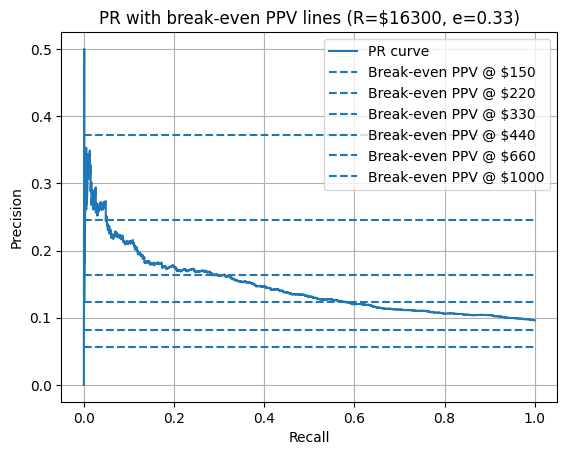

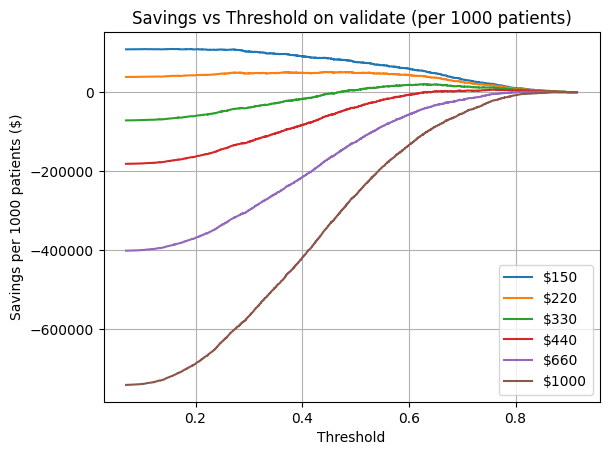

[COST] Chosen threshold: 0.6253 | PPV=0.162  Recall=0.323  FlagRate=0.191  Savings@$330=20.38 per patient
ROC_AUC:     0.6084145793018944
Accuracy:      0.774451437319272
F1 score:      0.20216606498194944
Precision:     0.15419917393299679
Recall:        0.2934497816593886

Confusion matrix:

TN: 8770, FP: 1843, FN: 809, TP: 336

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.83      0.87     10613
           1       0.15      0.29      0.20      1145

    accuracy                           0.77     11758
   macro avg       0.53      0.56      0.54     11758
weighted avg       0.84      0.77      0.80     11758

Duration: 0 hrs, 0 mins, 0.7 secs


In [7]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_pipe.test(
        c_m_list=m_cost_list,
        use_local_model=True,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        solver='adam',
        learning_rate_init=0.1,
        learning_rate='adaptive',
        hidden_layer_sizes=(100, 50),
        alpha=1e-05,
        activation='tanh'
    )
else:
    mlp_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Logistic Regression

Logistic Regression was included as a baseline model due to its interpretability and efficiency. It provides a well-understood probabilistic framework for binary classification, making it an ideal benchmark for evaluating more complex models.

In [8]:
lr_pipe = ModelPipeline(
    model='lr',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
)

In [9]:
if GET_BASELINE:
    lr_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [10]:
if SHOW_FEAT_IMPORTANCE:
    lr_pipe.permute_importance()

In [11]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    lr_param_dist = {
        'model__C': np.logspace(-4, 2, 20),
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 5),
    }

    lr_pipe.run_hyperparam_search(hyperparam_dist=lr_param_dist)

In [12]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    lr_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.5,
        C=0.01623776739188721
    )
else:
    lr_pipe.validate()

Held out validation metrics: lr
ROC_AUC:     0.6555284941161114
Accuracy:      0.6853646098929118
F1 score:      0.24170421958213847
Precision:     0.1572913889629432
Recall:        0.5216622458001768

Confusion matrix:

TN: 7474, FP: 3161, FN: 541, TP: 590

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80     10635
           1       0.16      0.52      0.24      1131

    accuracy                           0.69     11766
   macro avg       0.54      0.61      0.52     11766
weighted avg       0.86      0.69      0.75     11766

Duration: 0 hrs, 0 mins, 2.5 secs


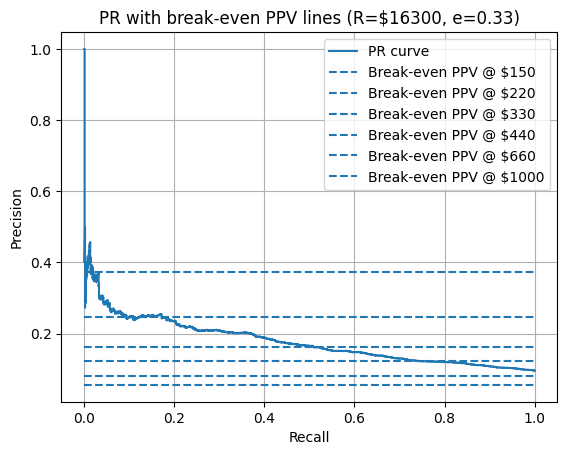

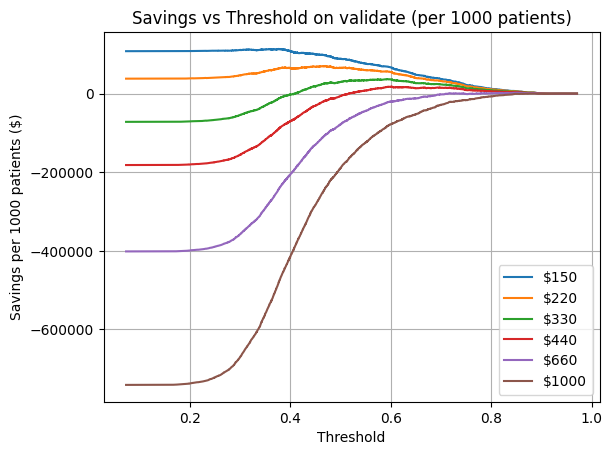

[COST] Chosen threshold: 0.5942 | PPV=0.201  Recall=0.370  FlagRate=0.177  Savings@$330=37.27 per patient
ROC_AUC:     0.6398173616685807
Accuracy:      0.7929069569654703
F1 score:      0.2472952086553323
Precision:     0.19138755980861244
Recall:        0.34934497816593885

Confusion matrix:

TN: 8923, FP: 1690, FN: 745, TP: 400

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.84      0.88     10613
           1       0.19      0.35      0.25      1145

    accuracy                           0.79     11758
   macro avg       0.56      0.60      0.56     11758
weighted avg       0.85      0.79      0.82     11758

Duration: 0 hrs, 0 mins, 1.1 secs


In [13]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    lr_pipe.test(
        use_local_model=True,
        show_duration_info=True,
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.5,
        C=0.6614527637660125,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF
    )
else:
    lr_pipe.test(
        prefer_c_m=COST_PREF,
        c_m_list=m_cost_list
    )

## K-Nearest Neighbors

KNN was included as a baseline non-parametric model to contrast with linear methods.

In [14]:
knn_pipe = ModelPipeline(
    model='knn',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
)

In [15]:
if GET_BASELINE:
    knn_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [16]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    knn_param_dist = {
        "model__n_neighbors": np.arange(3, 31, 2),
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan", "minkowski"],
        "model__p": [1, 2],
        "model__leaf_size": np.arange(10, 50, 5)
        }

    knn_pipe.run_hyperparam_search(hyperparam_dist=knn_param_dist)



In [17]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    knn_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.validate()

Held out validation metrics: knn
ROC_AUC:     0.5734690645346742
Accuracy:      0.620176780554139
F1 score:      0.19375789283781344
Precision:     0.12171350861287399
Recall:        0.47480106100795755

Confusion matrix:

TN: 6760, FP: 3875, FN: 594, TP: 537

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.64      0.75     10635
           1       0.12      0.47      0.19      1131

    accuracy                           0.62     11766
   macro avg       0.52      0.56      0.47     11766
weighted avg       0.84      0.62      0.70     11766

Duration: 0 hrs, 0 mins, 5.0 secs


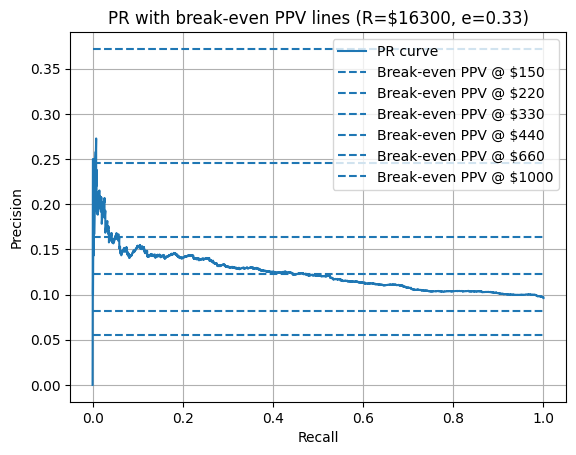

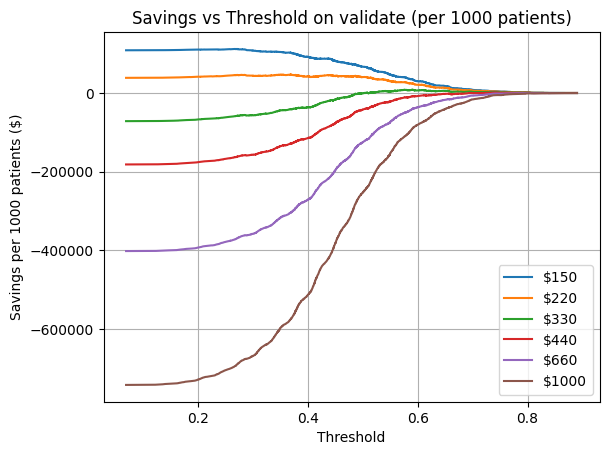

[COST] Chosen threshold: 0.5896 | PPV=0.144  Recall=0.222  FlagRate=0.148  Savings@$330=8.40 per patient
ROC_AUC:     0.5943388206850213
Accuracy:      0.7959687021602313
F1 score:      0.18318011576438542
Precision:     0.15011160714285715
Recall:        0.2349344978165939

Confusion matrix:

TN: 9090, FP: 1523, FN: 876, TP: 269

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.86      0.88     10613
           1       0.15      0.23      0.18      1145

    accuracy                           0.80     11758
   macro avg       0.53      0.55      0.53     11758
weighted avg       0.84      0.80      0.82     11758

Duration: 0 hrs, 0 mins, 0.9 secs


In [18]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    knn_pipe.test(
        c_m_list=m_cost_list,
        use_local_model=True,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Naive-bayes

In [20]:
nb_pipe = ModelPipeline(
    model='nb',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
)

In [21]:
if GET_BASELINE:
    nb_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )


In [22]:
if SHOW_FEAT_IMPORTANCE:
    nb_pipe.permute_importance()

In [23]:
if not USE_PRE_COMPUTED_HYPERPARAMS:

    gnb_param_dist = {
        "model__var_smoothing": np.logspace(-12, -6, 20)
    }

    nb_pipe.run_hyperparam_search(hyperparam_dist=gnb_param_dist)



In [24]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        var_smoothing=1e-06,
    )
else:
    nb_pipe.validate()

Held out validation metrics: nb
ROC_AUC:     0.5908156550635029
Accuracy:      0.7394186639469659
F1 score:      0.1952755905511811
Precision:     0.13885778275475924
Recall:        0.32891246684350134

Confusion matrix:

TN: 8328, FP: 2307, FN: 759, TP: 372

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.78      0.84     10635
           1       0.14      0.33      0.20      1131

    accuracy                           0.74     11766
   macro avg       0.53      0.56      0.52     11766
weighted avg       0.84      0.74      0.78     11766

Duration: 0 hrs, 0 mins, 1.7 secs


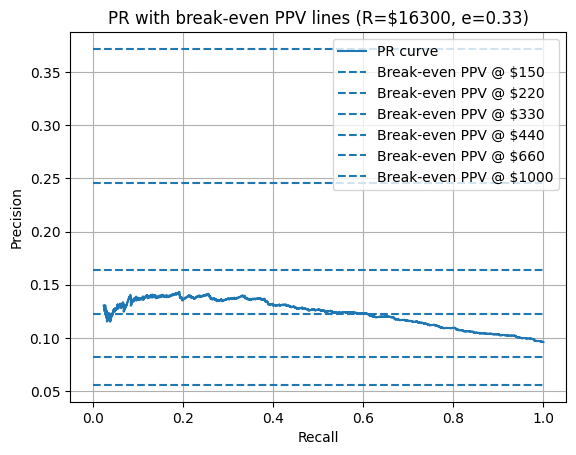

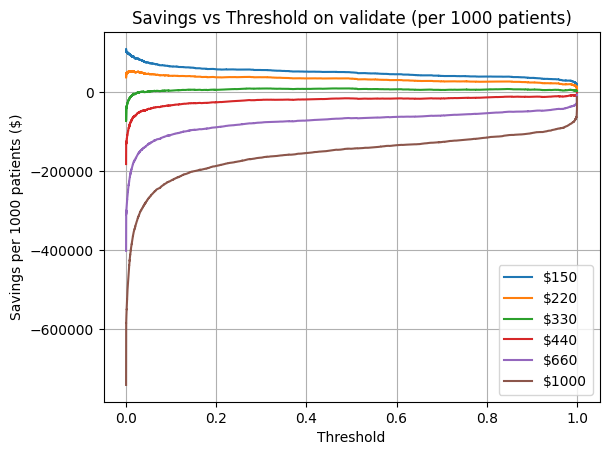

[COST] Chosen threshold: 0.4937 | PPV=0.140  Recall=0.332  FlagRate=0.228  Savings@$330=10.61 per patient
ROC_AUC:     0.591283409940104
Accuracy:      0.7352440891308045
F1 score:      0.18911174785100288
Precision:     0.13474387527839643
Recall:        0.3170305676855895

Confusion matrix:

TN: 8282, FP: 2331, FN: 782, TP: 363

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.78      0.84     10613
           1       0.13      0.32      0.19      1145

    accuracy                           0.74     11758
   macro avg       0.52      0.55      0.52     11758
weighted avg       0.84      0.74      0.78     11758

Duration: 0 hrs, 0 mins, 0.5 secs


In [25]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.test(
        use_local_model=True,
        show_duration_info=True,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        var_smoothing=1e-06,
        plot_pr_curves=False
        

    )
else:
    nb_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Random Forest

RF was the first model chosen after reading (Liu, V. et al.) and (Mahmoud, M. et al.) which showed it had very good performance among their tested models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

In [25]:
model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=False,                # show the target distribution between splits
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model='rf',
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
)

In [26]:
if GET_BASELINE:
    model_pipe.run_baseline(
        run_smote=True,
        run_undersampler=True,
        show_duration_info=True,
    )

In [27]:
if SHOW_FEAT_IMPORTANCE:
    model_pipe.permute_importance(
        print_num=15,
        plot=True,
        show_duration_info=True
    )

In [28]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_grid = {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10, 15, 20],
            'model__min_samples_leaf': [1, 2, 4, 6, 10],
            'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
            'model__class_weight': [None, 'balanced'],
            'model__bootstrap': [True, False],
            'model__oob_score': [True, False]
        }

    model_pipe.run_hyperparam_search(
        hyperparam_dist=param_grid,
        param_scoring='roc_auc',
        n_iter=30,
        n_jobs=-1,
        refit=True,
        show_duration_info=True
    )

In [29]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )

else:
    model_pipe.validate(
        show_duration_info=False,
        use_local_model=False
    )

Held out validation metrics: rf
ROC_AUC:     0.6549699726101652
Accuracy:      0.6515383307836138
F1 score:      0.23564504101416853
Precision:     0.14930309473186865
Recall:        0.5587975243147657

Confusion matrix:

TN: 7034, FP: 3601, FN: 499, TP: 632

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77     10635
           1       0.15      0.56      0.24      1131

    accuracy                           0.65     11766
   macro avg       0.54      0.61      0.50     11766
weighted avg       0.86      0.65      0.72     11766

Duration: 0 hrs, 0 mins, 2.6 secs


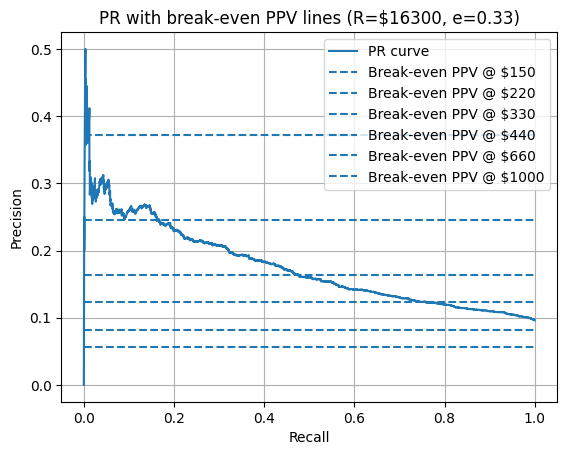

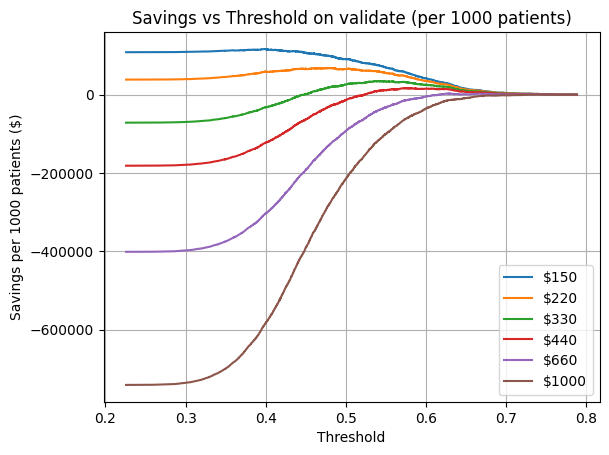

[COST] Chosen threshold: 0.5413 | PPV=0.181  Recall=0.422  FlagRate=0.224  Savings@$330=35.02 per patient
ROC_AUC:     0.6472148148209105
Accuracy:      0.7561660146283381
F1 score:      0.24493020805899393
Precision:     0.1753393665158371
Recall:        0.40611353711790393

Confusion matrix:

TN: 8426, FP: 2187, FN: 680, TP: 465

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85     10613
           1       0.18      0.41      0.24      1145

    accuracy                           0.76     11758
   macro avg       0.55      0.60      0.55     11758
weighted avg       0.85      0.76      0.80     11758



In [30]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )
else:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Stochastic Gradient Descent Classifier

SGDClassifier was included because it scales efficiently to high-dimensional data and provides a fast, linear baseline that incorporates regularization. With hinge or logistic loss, it approximates SVMs or logistic regression while training orders of magnitude faster, which is helpful for rapid iteration and hyperparameter exploration.

In [ ]:
sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    plot_y_dist=False,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model='sgd',
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
)

In [32]:
if SHOW_FEAT_IMPORTANCE:
    sgd_pipe.run_baseline() # all true

----------Running Feature Importance for model: sgd----------


,feature,importance_mean,importance_std
10,v_inpatient_group,0.059125,0.017989
4,number_diagnoses,0.007330,0.005653
9,v_emergency_group,0.005530,0.002759
18,diag1_group_musculoskeletal,0.004481,0.001757
63,diabetesMed_flag,0.003204,0.001647
67,num_drugs,0.002754,0.001513
12,weight_group,0.002096,0.001928
0,time_in_hospital,0.001975,0.004450
5,age_group,0.001921,0.003907
28,diag2_group_neoplasms,0.001853,0.001970


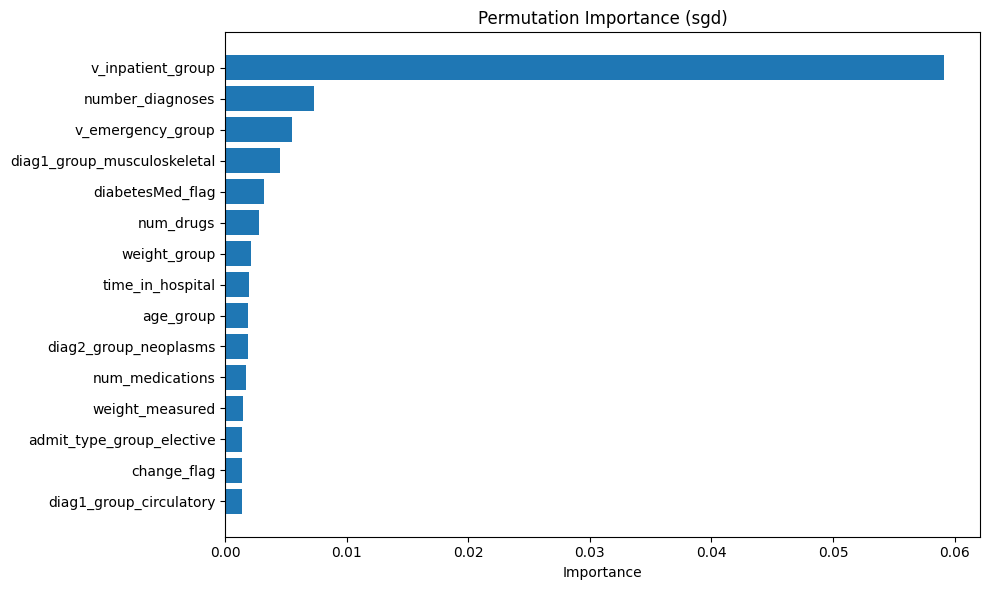

Duration: 0 hrs, 0 mins, 25.3 secs


In [33]:
if not SHOW_FEAT_IMPORTANCE:
    sgd_pipe.permute_importance()

In [34]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_param_grid = {
        "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        "model__l1_ratio": [0.1, 0.5, 0.9],
        "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
        "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
        "model__max_iter": [100, 500, 1000],
        "model__tol": [1e-3, 1e-4],
        "model__class_weight": [None, "balanced"],
        "model__average": [False, True, 5, 10],
        "model__shuffle": [True],
    }

    sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

In [28]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
        )
else:
    sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6536973782827584
Accuracy:      0.9038755736868944
F1 score:      0.0
Precision:     0.0
Recall:        0.0

Confusion matrix:

TN: 10635, FP: 0, FN: 1131, TP: 0

Classification report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95     10635
           1       0.00      0.00      0.00      1131

    accuracy                           0.90     11766
   macro avg       0.45      0.50      0.47     11766
weighted avg       0.82      0.90      0.86     11766

Duration: 0 hrs, 0 mins, 1.9 secs


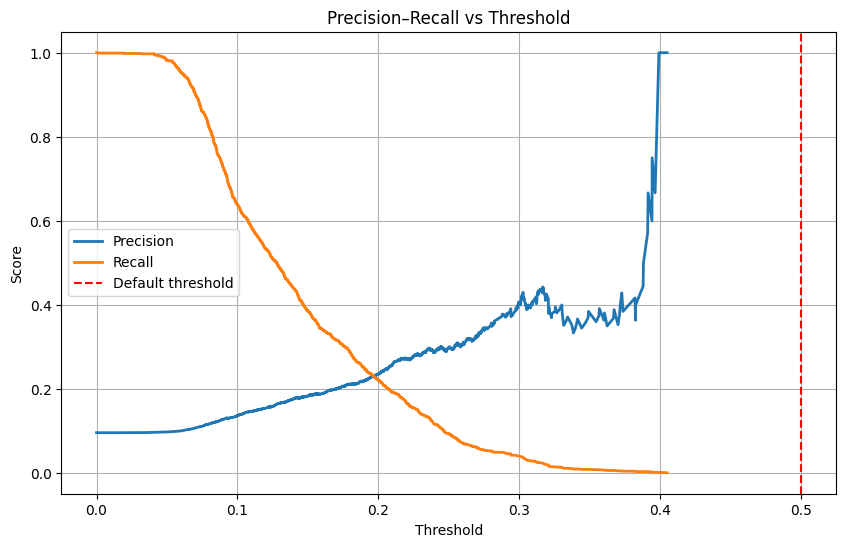

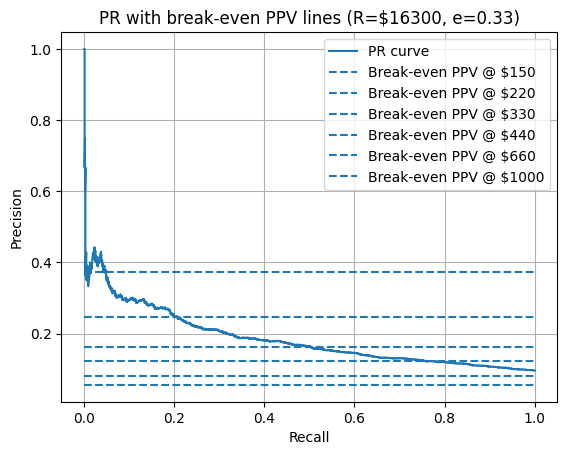

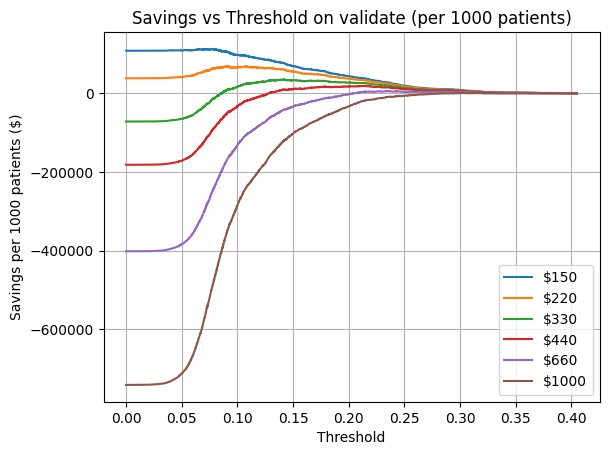

[COST] Chosen threshold: 0.1416 | PPV=0.179  Recall=0.434  FlagRate=0.233  Savings@$330=35.41 per patient
ROC_AUC:     0.6415003927374231
Accuracy:      0.7517434937914611
F1 score:      0.24122693007538343
Precision:     0.17172464840858623
Recall:        0.4052401746724891

Confusion matrix:

TN: 8375, FP: 2238, FN: 681, TP: 464

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85     10613
           1       0.17      0.41      0.24      1145

    accuracy                           0.75     11758
   macro avg       0.55      0.60      0.55     11758
weighted avg       0.85      0.75      0.79     11758

Duration: 0 hrs, 0 mins, 0.6 secs


In [ ]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
    )

else:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Support Vector Classifier

SVM was included because it provides a strong, theoretically grounded non-linear classifier that often performs well on medium-sized tabular datasets.

In [37]:
svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    plot_y_dist=False,
    use_pca=PCA,
    create_interactions=True)

In [38]:
if GET_BASELINE:
    svc_pipe.run_baseline(run_smote=False)

In [39]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    from scipy.stats import loguniform
    svc_param_grid = {
        "model__C": loguniform(1e-3, 1e3),
        "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],
    }

    svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

In [40]:
if USE_PRE_COMPUTED_HYPERPARAMS:
        svc_pipe.validate(
        use_local_model=True,
        C=3.8115440886530614,
        gamma=.001
    )
else:
    svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6567872875250922
Accuracy:      0.7378888322284549
F1 score:      0.24853801169590642
Precision:     0.1715438950554995
Recall:        0.4509283819628647

Confusion matrix:

TN: 8172, FP: 2463, FN: 621, TP: 510

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84     10635
           1       0.17      0.45      0.25      1131

    accuracy                           0.74     11766
   macro avg       0.55      0.61      0.54     11766
weighted avg       0.86      0.74      0.78     11766



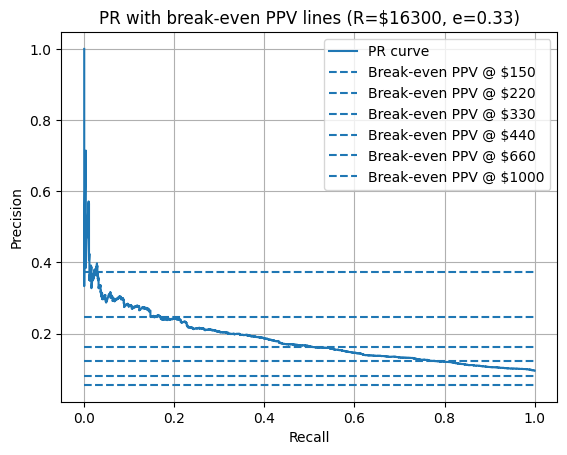

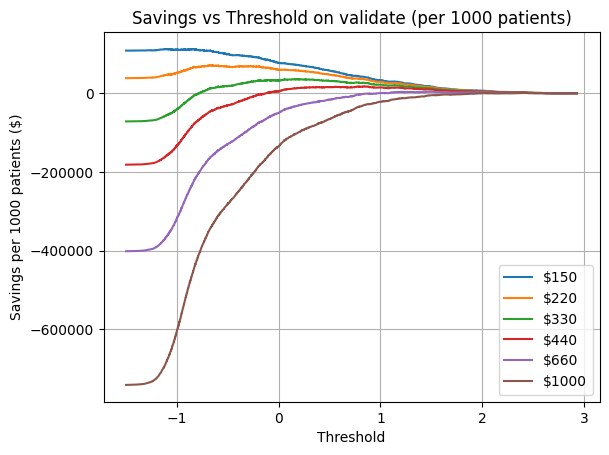

[COST] Chosen threshold: 0.1519 | PPV=0.186  Recall=0.407  FlagRate=0.210  Savings@$330=35.82 per patient
ROC_AUC:     0.6393399048789551
Accuracy:      0.7652662017349889
F1 score:      0.24175824175824176
Precision:     0.17635270541082165
Recall:        0.38427947598253276

Confusion matrix:

TN: 8558, FP: 2055, FN: 705, TP: 440

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86     10613
           1       0.18      0.38      0.24      1145

    accuracy                           0.77     11758
   macro avg       0.55      0.60      0.55     11758
weighted avg       0.85      0.77      0.80     11758



In [41]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Extreme Gradient Boosting

XGBoost was chosen after previous studies had found it to be the best performing model of their tested sets.

In [2]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    plot_y_dist=False,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    resample=False # handled by hyperparameters
)

In [3]:
if GET_BASELINE:
    xgb_pipe.run_baseline()

In [4]:
if SHOW_FEAT_IMPORTANCE:
    xgb_pipe.permute_importance()

In [5]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_dist = {
        'model__max_depth': [3,4,5],
        'model__min_child_weight': [1,2,4],
        'model__subsample': [0.6,0.8,1.0],
        'model__colsample_bytree': [0.6,0.8,1.0],
        'model__gamma': [0,1,3],
        'model__learning_rate': [0.02, 0.05, 0.1],
        'model__scale_pos_weight': [1,2,4,6,8,10]
    }

    xgb_pipe.run_hyperparam_search(
        hyperparam_dist=param_dist
    )

In [6]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.validate(
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )
else:
    xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6631288095419218
Accuracy:      0.8731089580146184
F1 score:      0.20963472736897829
Precision:     0.2612137203166227
Recall:        0.17506631299734748

Confusion matrix:

TN: 10075, FP: 560, FN: 933, TP: 198

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93     10635
           1       0.26      0.18      0.21      1131

    accuracy                           0.87     11766
   macro avg       0.59      0.56      0.57     11766
weighted avg       0.85      0.87      0.86     11766



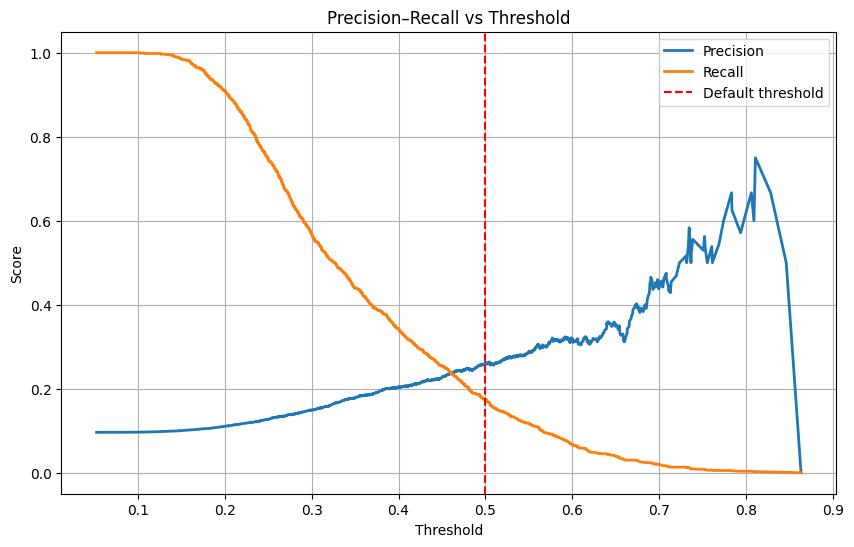

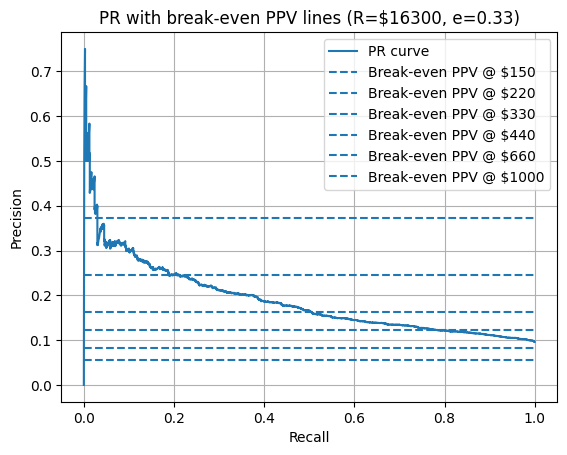

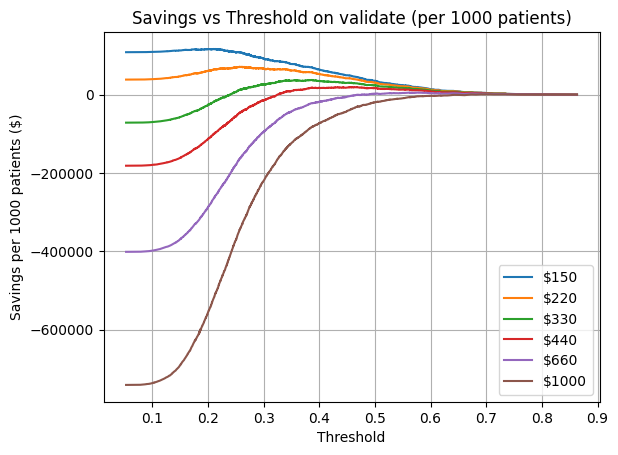

[COST] Chosen threshold: 0.3858 | PPV=0.200  Recall=0.376  FlagRate=0.180  Savings@$330=37.69 per patient
ROC_AUC:     0.6499020110871687
Accuracy:      0.7927368600102058
F1 score:      0.2452771755961598
Precision:     0.19001919385796545
Recall:        0.34585152838427946

Confusion matrix:

TN: 8925, FP: 1688, FN: 749, TP: 396

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.84      0.88     10613
           1       0.19      0.35      0.25      1145

    accuracy                           0.79     11758
   macro avg       0.56      0.59      0.56     11758
weighted avg       0.85      0.79      0.82     11758



In [ ]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8,
        plot_pr_curves=False
    )

else:

    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Results Comparison

Here we compare the metrics between runs.

Data was logged for each run to a database, dumped to a csv and is included in the pip package

In [50]:
import pandas as pd
from shared_util.pd_util import filter_df
from shared_util.dataio import load_csv
# use exported csv not database to get metrics in the collab notebook


metrics_df = load_csv('metrics').reset_index()
#display(metrics_df.head(5))

test_df = filter_df(metrics_df, data=['test'])
most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])
filter_df(most_recent_df, data='test').sort_values(by='roc_auc', ascending=False).head(8)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
139,551,32,xgb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.649902,0.792737,0.190019,0.345852,0.245277,8925.0,396.0,1688.0,749.0,37.688042,2025-11-22 20:24:47.734960
154,545,32,rf,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.647215,0.756166,0.175339,0.406114,0.244930,8426.0,465.0,2187.0,680.0,35.017976,2025-11-22 20:23:25.671793
229,547,32,sgd,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.639884,0.779639,0.182616,0.363319,0.243062,8751.0,416.0,1862.0,729.0,35.393804,2025-11-22 20:23:56.318977
230,539,32,lr,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.639817,0.792907,0.191388,0.349345,0.247295,8923.0,400.0,1690.0,745.0,37.270143,2025-11-22 20:23:04.893162
253,549,32,svc,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.639340,0.765266,0.176353,0.384279,0.241758,8558.0,440.0,2055.0,705.0,35.815910,2025-11-22 20:24:43.438510
313,537,32,mlp,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.608415,0.774451,0.154199,0.293450,0.202166,8770.0,336.0,1843.0,809.0,20.383095,2025-11-22 20:22:57.807799
353,541,32,knn,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.594339,0.795969,0.150112,0.234934,0.183180,9090.0,269.0,1523.0,876.0,8.404258,2025-11-22 20:23:13.309026
378,543,32,nb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,ordinal_a1c_gluc,0.591283,0.735244,0.134744,0.317031,0.189112,8282.0,363.0,2331.0,782.0,10.612953,2025-11-22 20:23:18.927909


## Comparing Models

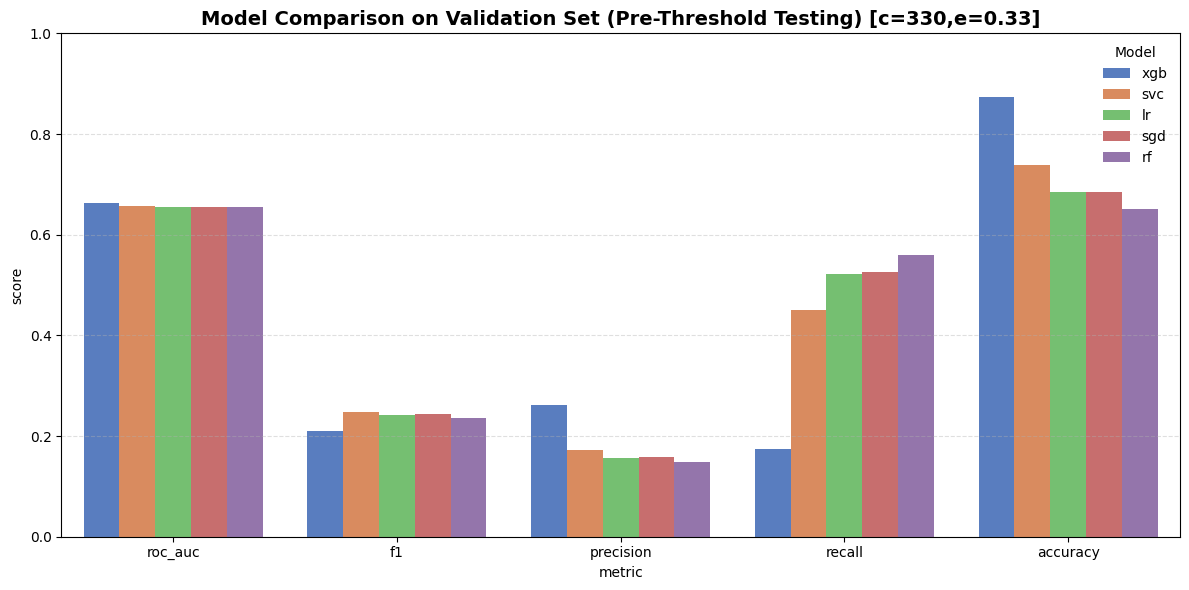

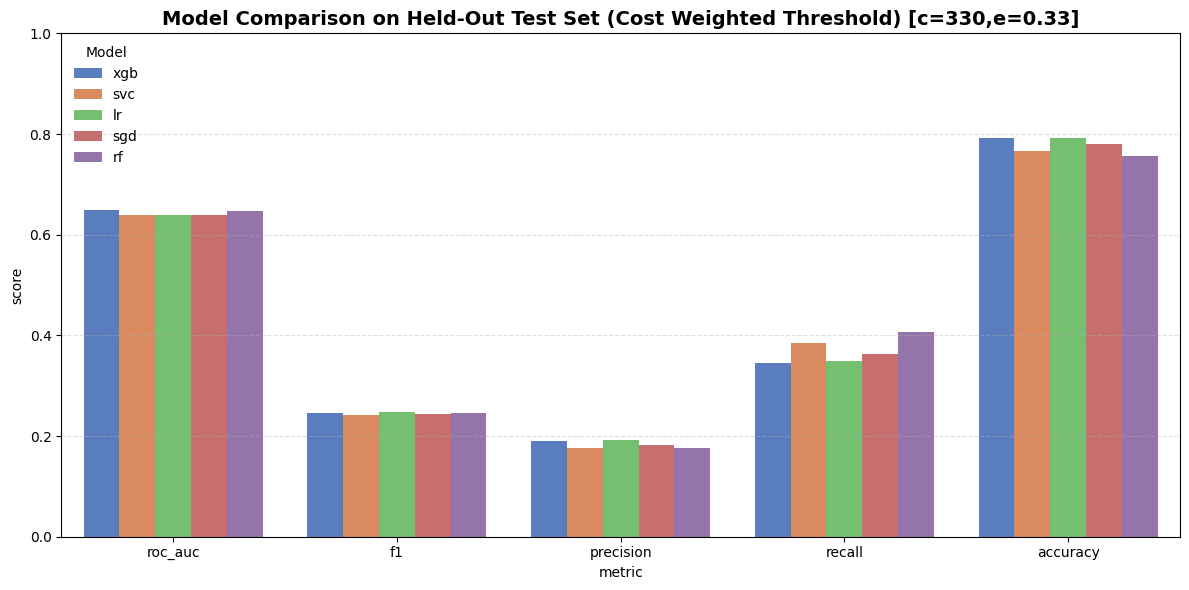

In [51]:
from shared_util.metrics.printing import summary_by
from shared_util.metrics.plotting import plot_metrics

top_5_models = filter_df(most_recent_df, model=['rf', 'xgb', 'lr', 'svc', 'sgd']).sort_values(by='roc_auc', ascending=False)

plot_metrics(top_5_models, METRICS_DB_ID, 'c=330,e=0.33', palette='muted')

In [52]:
print('--most recent--')


summary_by(most_recent_df, col='roc_auc')
summary_by(most_recent_df, col='recall')
summary_by(most_recent_df, col='precision')
summary_by(most_recent_df, col='est_pp_savings')
summary_by(most_recent_df, col='accuracy')

--most recent--
Models by roc_auc


,model,roc_auc
139,xgb,0.650
154,rf,0.647
229,sgd,0.640
230,lr,0.640
253,svc,0.639
313,mlp,0.608
353,knn,0.594
378,nb,0.591


Models by recall


,model,recall
154,rf,0.406
253,svc,0.384
229,sgd,0.363
230,lr,0.349
139,xgb,0.346
378,nb,0.317
313,mlp,0.293
353,knn,0.235


Models by precision


,model,precision
230,lr,0.191
139,xgb,0.190
229,sgd,0.183
253,svc,0.176
154,rf,0.175
313,mlp,0.154
353,knn,0.150
378,nb,0.135


Models by est_pp_savings


,model,est_pp_savings
139,xgb,37.688
230,lr,37.270
253,svc,35.816
229,sgd,35.394
154,rf,35.018
313,mlp,20.383
378,nb,10.613
353,knn,8.404


Models by accuracy


,model,accuracy
353,knn,0.796
230,lr,0.793
139,xgb,0.793
229,sgd,0.780
313,mlp,0.774
253,svc,0.765
154,rf,0.756
378,nb,0.735


Average ROC_AUC between validate and test splits

In [ ]:
_test_val = filter_df(most_recent_df, data=['test', 'validate']).groupby(by='model', as_index=False)['roc_auc'].mean()

_test_val.sort_values(by='roc_auc', ascending=False) #type: ignore

## Comparing Different Runs

We can compare the metrics precision, f1, accuracy, recall between different runs given that we set the input variabels (c_m and e)

This shows how the predictions change by adjusting the input costs.

In [4]:
from shared_util.pd_util import filter_df

_run_ids = [28,29,30,31]

results_df = filter_df(test_df, run_id=_run_ids)

run_notes = pd.DataFrame({
    "run_id": _run_ids,
    "label": ['e=0.33_c=330','e=0.50_c=330','e=0.50_c=150','e=0.25_c=330']
})

df_means = results_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')



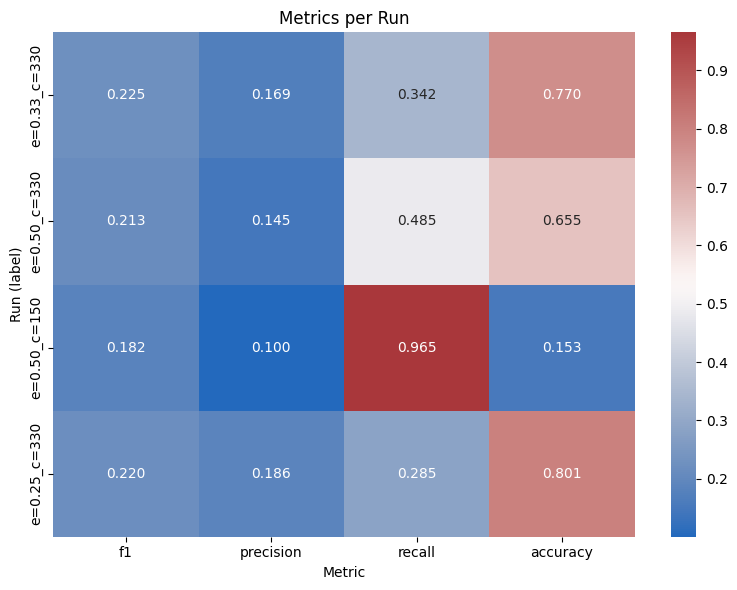

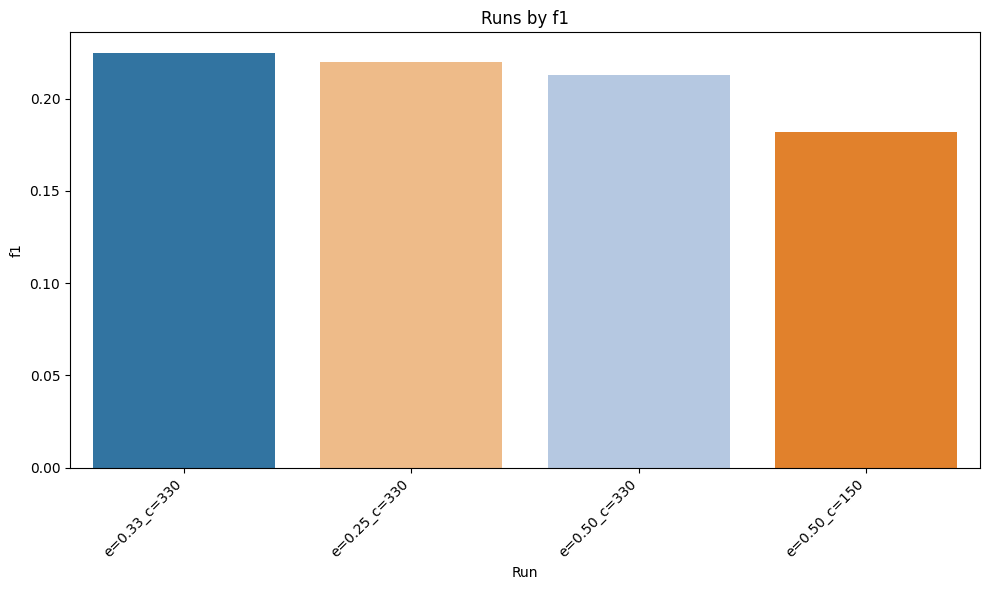

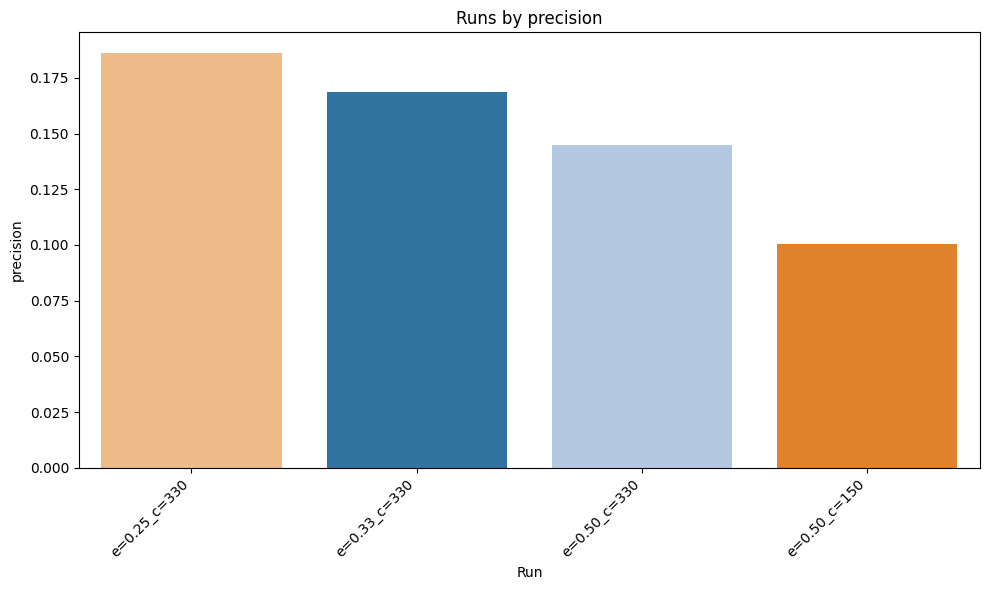

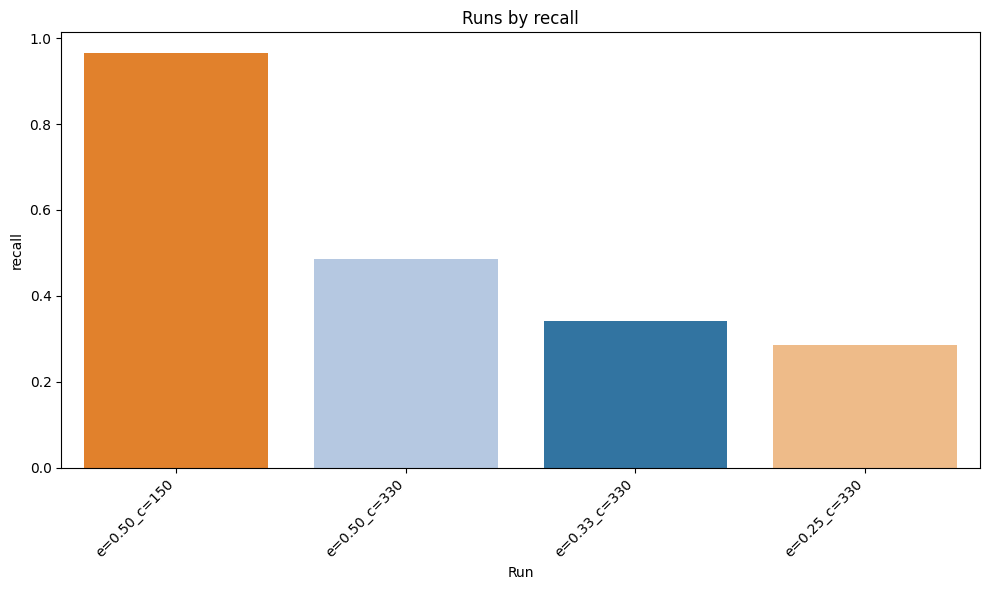

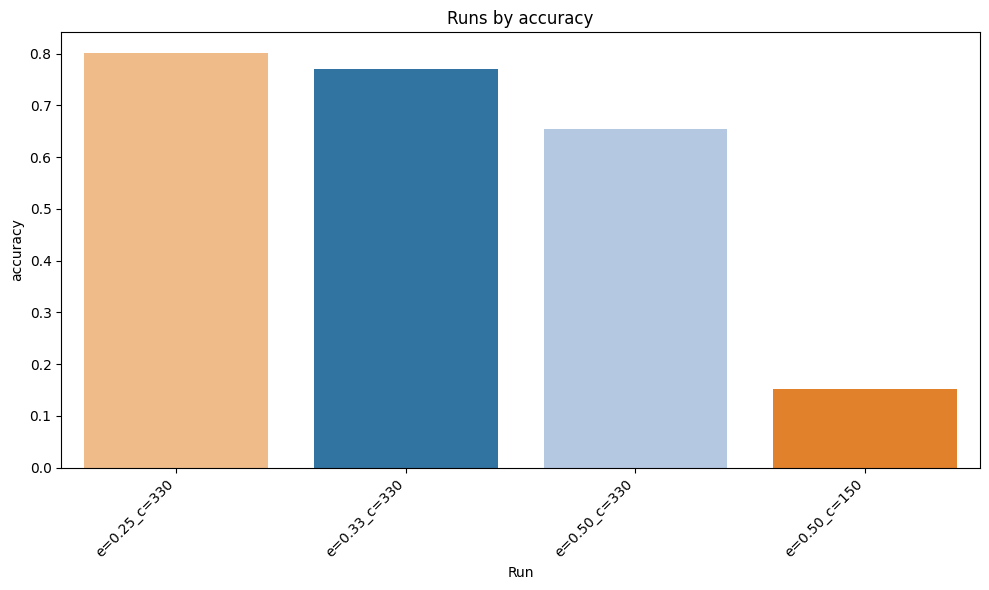

In [5]:
from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label,
    metric_cols=["f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

In [ ]:
from shared_util.metrics.compare import print_run_compare

print_run_compare(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,13,"c=440,e=0.25",0.750,9.0,0.673558,0.267766,0.182189,0.508036,0.729728
1,14,"c=330,e=0.25",0.625,11.0,0.673558,0.218237,0.126919,0.780843,0.455317
2,16,"c=330,e=0.33",0.500,13.0,0.673558,0.190005,0.105668,0.941573,0.219444
3,12,"c=440,e=0.50",0.375,15.0,0.673558,0.188653,0.104769,0.947654,0.207028
4,15,"c=330,e=0.45",0.250,17.0,0.673558,0.180886,0.099597,0.984144,0.133352



=== Top 5 by roc_auc ===


,run_id,label,roc_auc
0,13,"c=440,e=0.25",0.673558
1,14,"c=330,e=0.25",0.673558
2,16,"c=330,e=0.33",0.673558
3,12,"c=440,e=0.50",0.673558
4,15,"c=330,e=0.45",0.673558



=== Top 5 by f1 ===


...

,run_id,label,precision
0,13,"c=440,e=0.25",0.182189
1,14,"c=330,e=0.25",0.126919
2,16,"c=330,e=0.33",0.105668
3,12,"c=440,e=0.50",0.104769
4,15,"c=330,e=0.45",0.099597



=== Top 5 by recall ===


,run_id,label,recall
4,15,"c=330,e=0.45",0.984144
3,12,"c=440,e=0.50",0.947654
2,16,"c=330,e=0.33",0.941573
1,14,"c=330,e=0.25",0.780843
0,13,"c=440,e=0.25",0.508036



=== Top 5 by accuracy ===


,run_id,label,accuracy
0,13,"c=440,e=0.25",0.729728
1,14,"c=330,e=0.25",0.455317
2,16,"c=330,e=0.33",0.219444
3,12,"c=440,e=0.50",0.207028
4,15,"c=330,e=0.45",0.133352


### Quickly Check scores for last 2 runs


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,25,last-run,0.8,6.0,0.623736,0.220926,0.171665,0.333515,0.776089
1,24,penultimate,0.2,9.0,0.620782,0.220289,0.163201,0.345103,0.762958



=== Top 2 by roc_auc ===


,run_id,label,roc_auc
0,25,last-run,0.623736
1,24,penultimate,0.620782



=== Top 2 by f1 ===


...

,run_id,label,precision
0,25,last-run,0.171665
1,24,penultimate,0.163201



=== Top 2 by recall ===


,run_id,label,recall
1,24,penultimate,0.345103
0,25,last-run,0.333515



=== Top 2 by accuracy ===


,run_id,label,accuracy
0,25,last-run,0.776089
1,24,penultimate,0.762958


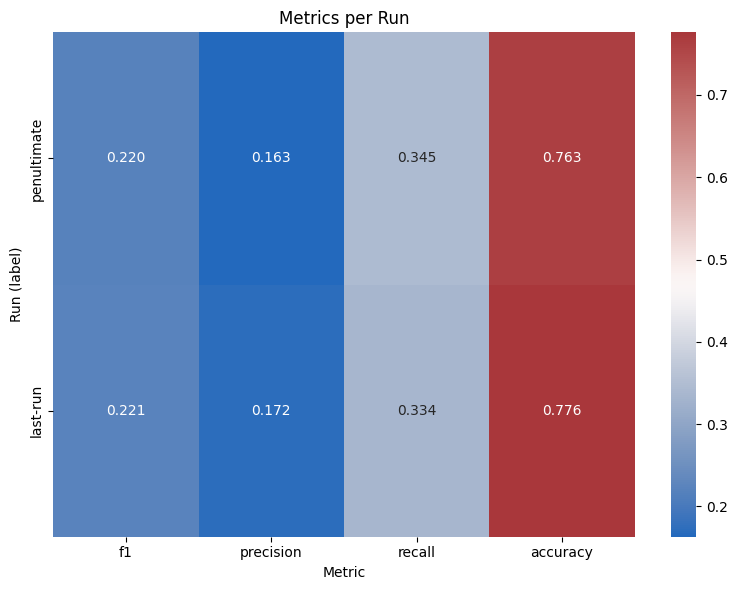

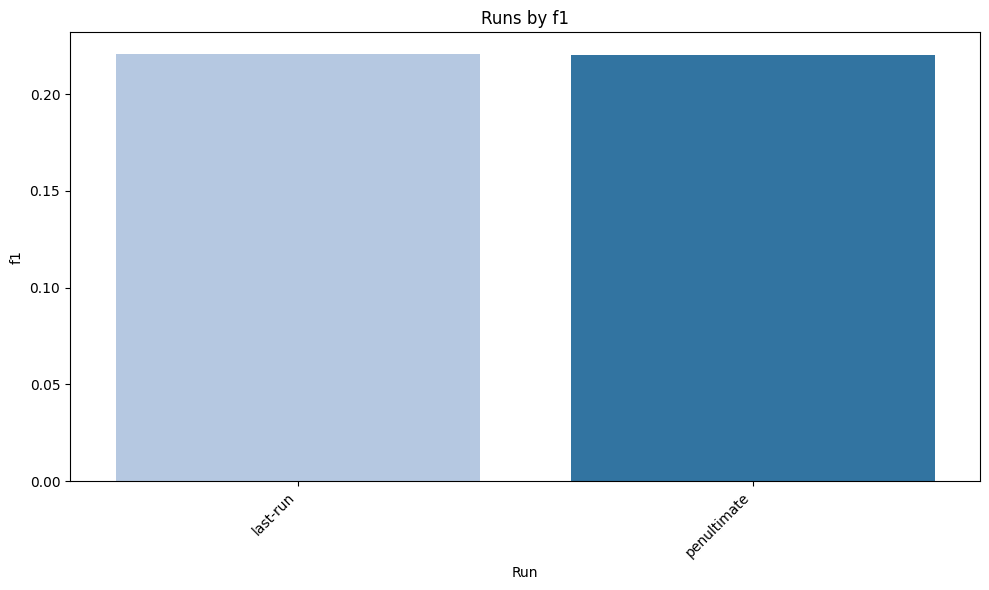

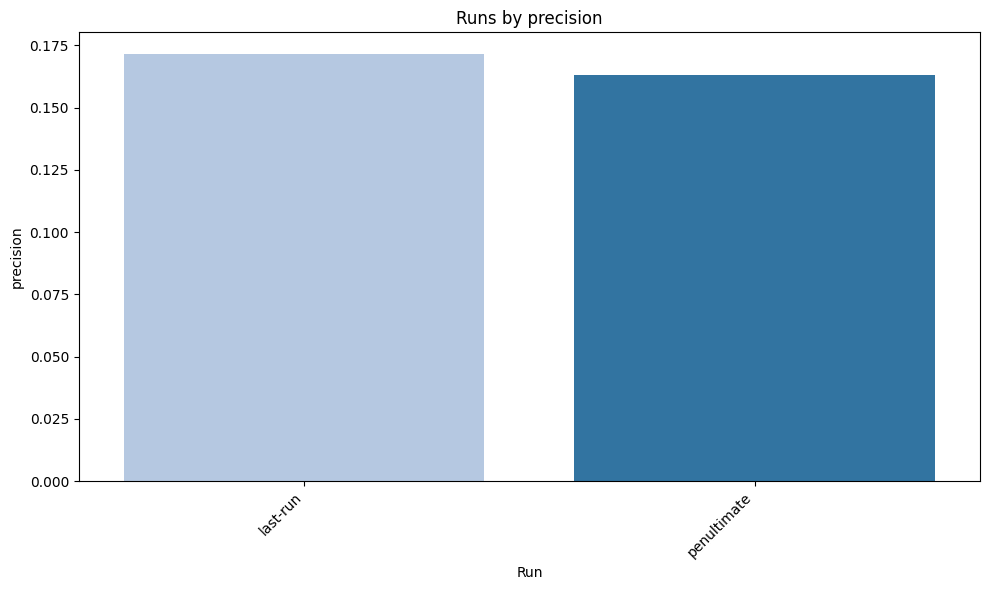

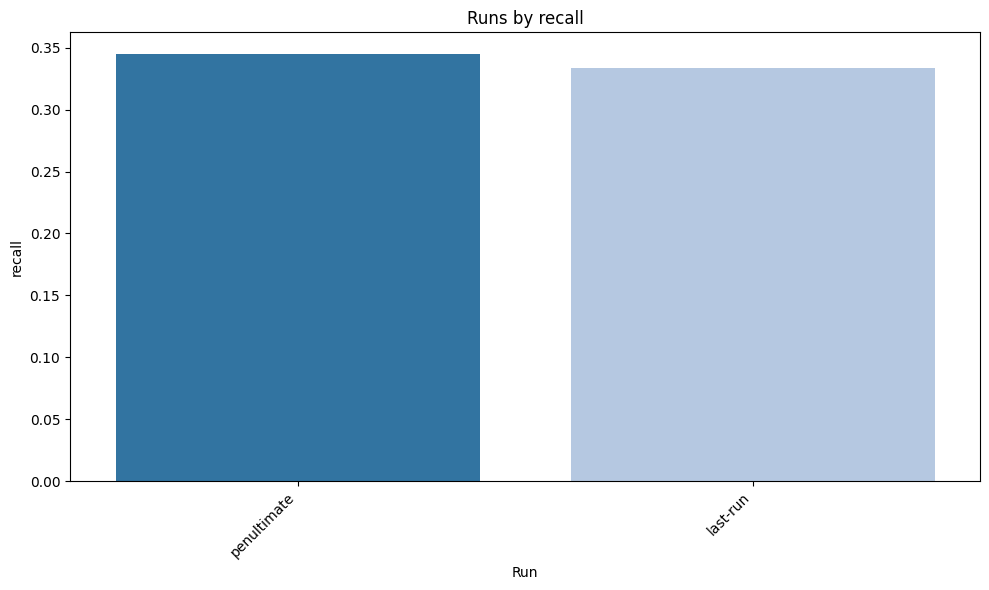

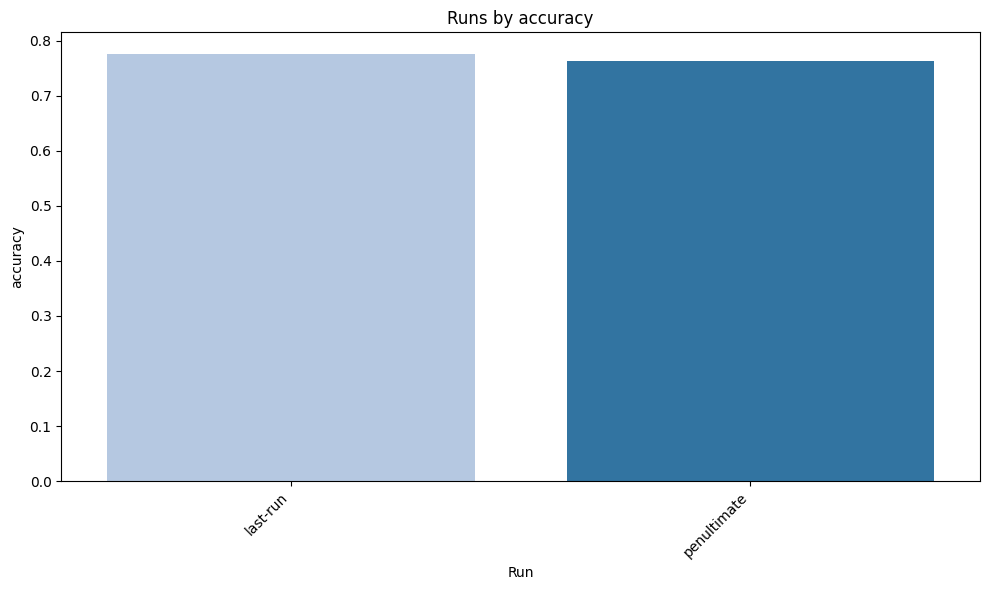

In [49]:
from shared_util.pd_util import filter_df

run_ids = [METRICS_DB_ID-1, METRICS_DB_ID]

weight_test = filter_df(test_df, run_id=run_ids)

run_notes = pd.DataFrame({
    "run_id": run_ids,
    "label": ['penultimate', 'last-run']
})

df_means_w = weight_test.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label_w = df_means_w.merge(run_notes, on='run_id', how='left')

from shared_util.metrics.compare import print_run_compare

print_run_compare(
    df= df_label_w,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)
from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label_w,
    metric_cols=["f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

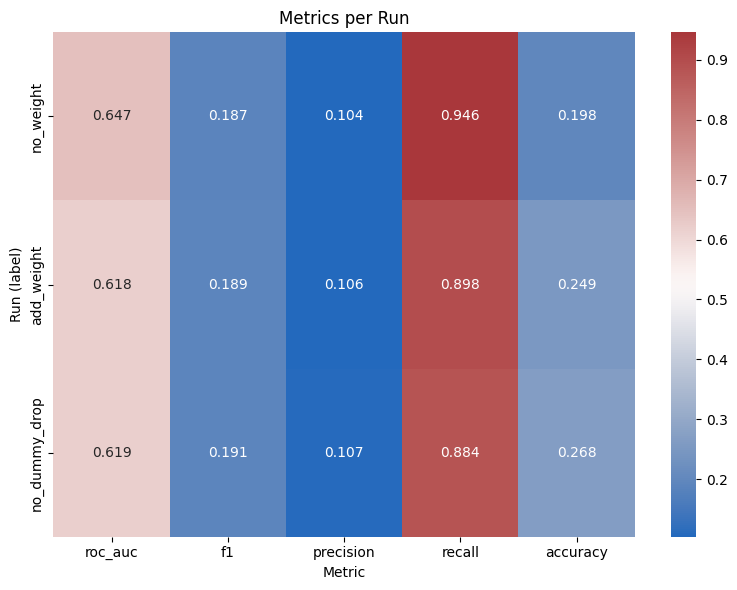

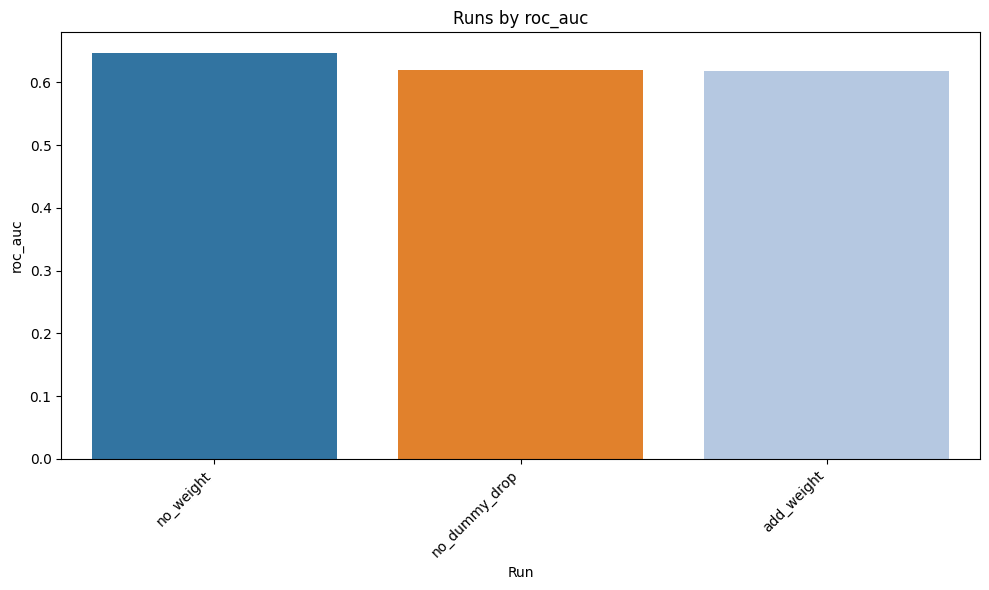

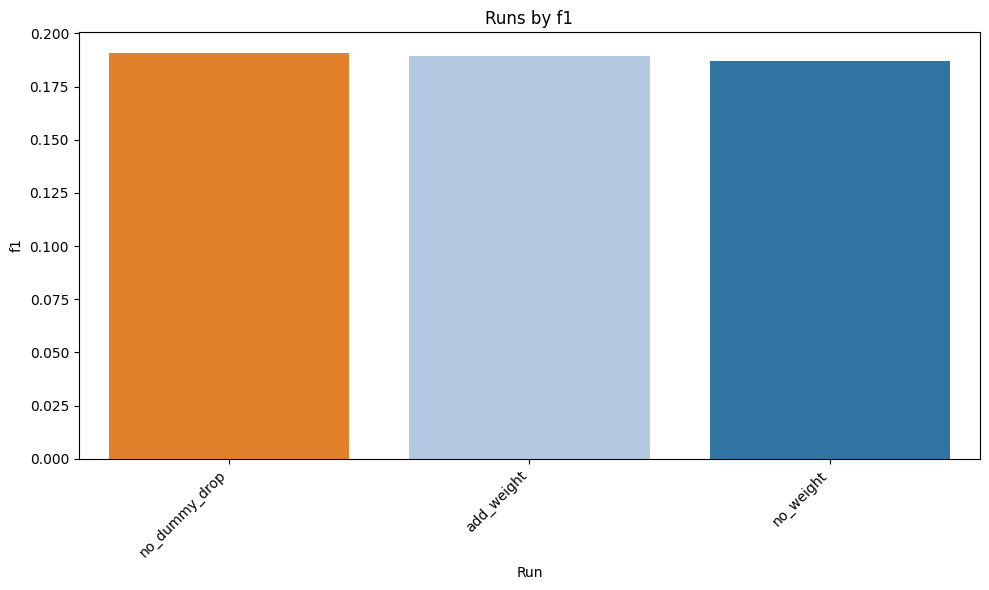

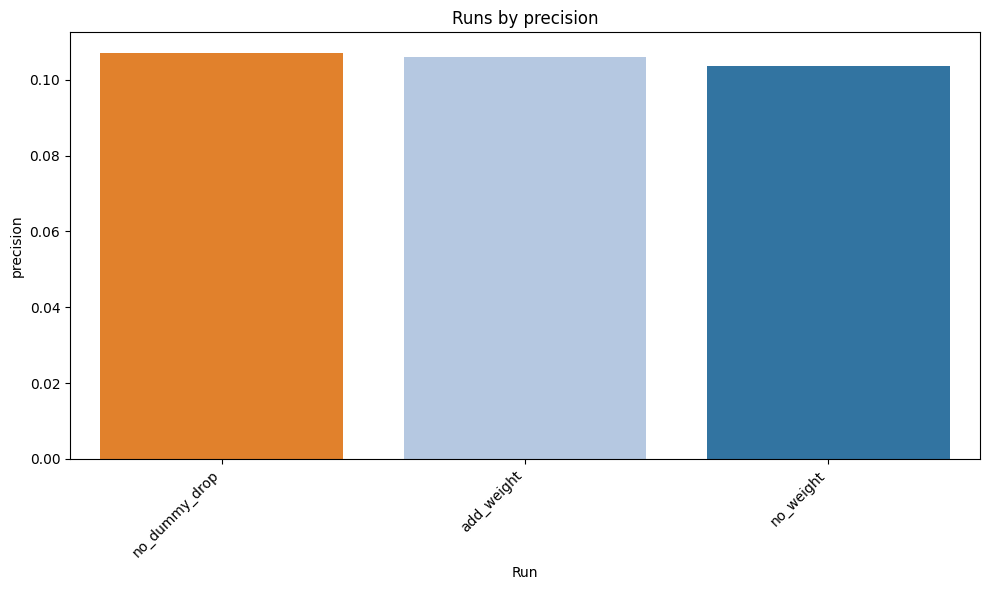

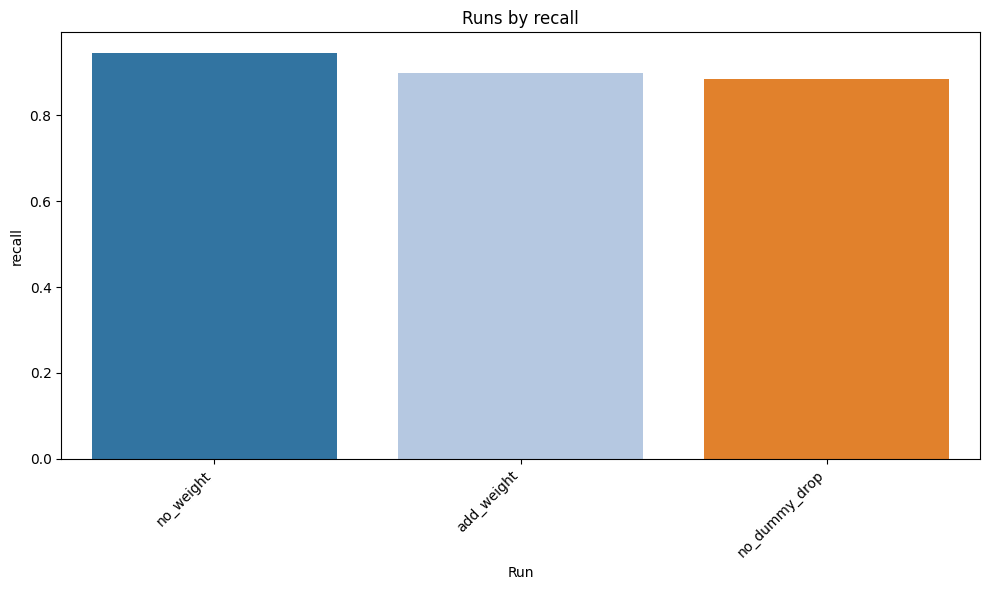

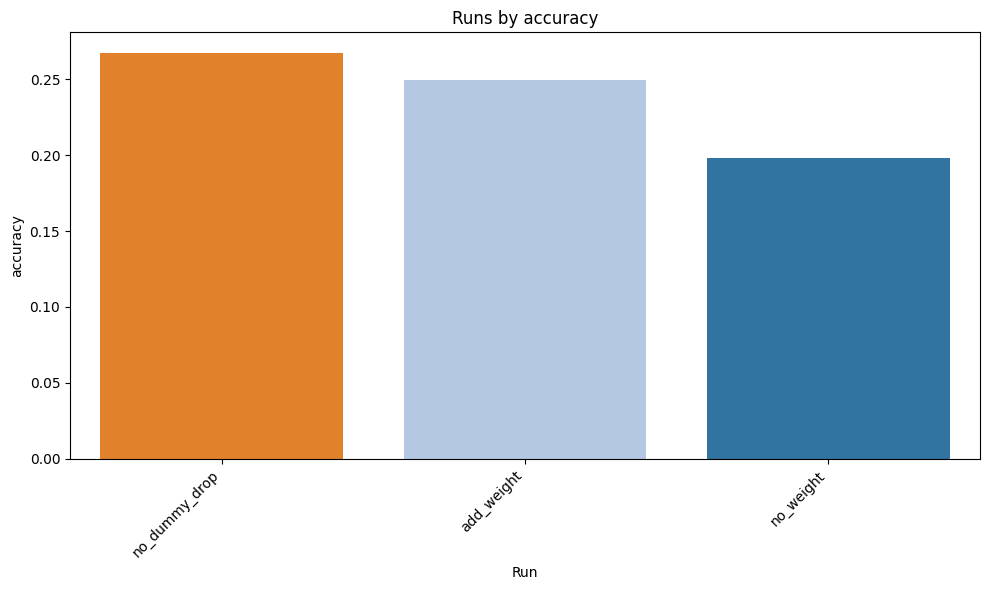

In [67]:
from shared_util.pd_util import filter_df

results_df2 = filter_df(test_df, run_id=[17,18,19])

run_notes2 = pd.DataFrame({
    "run_id": [17,18,19],
    "label": ['no_weight', 'add_weight', 'no_dummy_drop']
})

df_means2 = results_df2.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label2 = df_means2.merge(run_notes2, on='run_id', how='left')

from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label2,
    metric_cols=['roc_auc', "f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)